# Modelos de Series Temporais

Neste script axustaremos modelos de series temporais ao data frame filtrado (sen outliers).

## Funcións

Librarías e funcións precisas para o traballo. Ditas funcións atópanse no script Funcións.ipnynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
import Funcions as ft

print("Entorno configurado e librarías cargadas.")

Entorno configurado e librarías cargadas.


## Lectura dos datos

Carga e lectura de datos.

In [2]:
ruta = 'TFM_datos_EDA_outliers.csv'
datos = ft.cargar_e_preparar_datos(ruta)

Cargando datos dende: TFM_datos_EDA_outliers.csv
   Datos procesados: Atopáronse 3 clusters.


## Series de Tempo univariantes

Dicionarios para gardar distintos resultados e información precisa nos modelos.

In [3]:
export_para_prophet = {}
datos_arima = {}
fechas_bf = pd.to_datetime(['2022-11-21', '2023-11-20', '2024-11-25'])

### Modelo xeral

In [4]:
df_global = datos['Global'].set_index('semana')

#### Análise de intervención: efecto do Black Friday

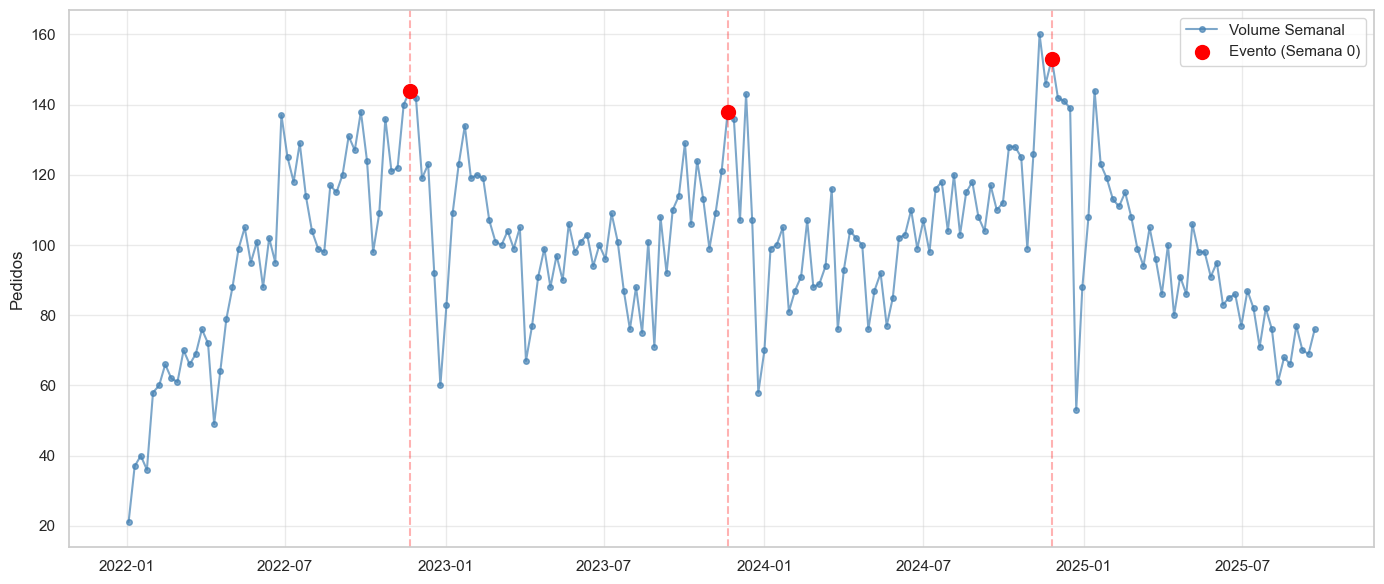

In [5]:
ft.plot_analisis_intervencion(df_input=df_global,
                              fechas_clave=fechas_bf)

Modélase o impacto do Black Friday nas dúas semanas previas e nas dúas posteriores.

In [9]:
modelo = 'Global'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_global)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=2, 
        weeks_post=2 
    )
cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q)X(P,D,Q)

#### Gráfico secuencial, fas e fap

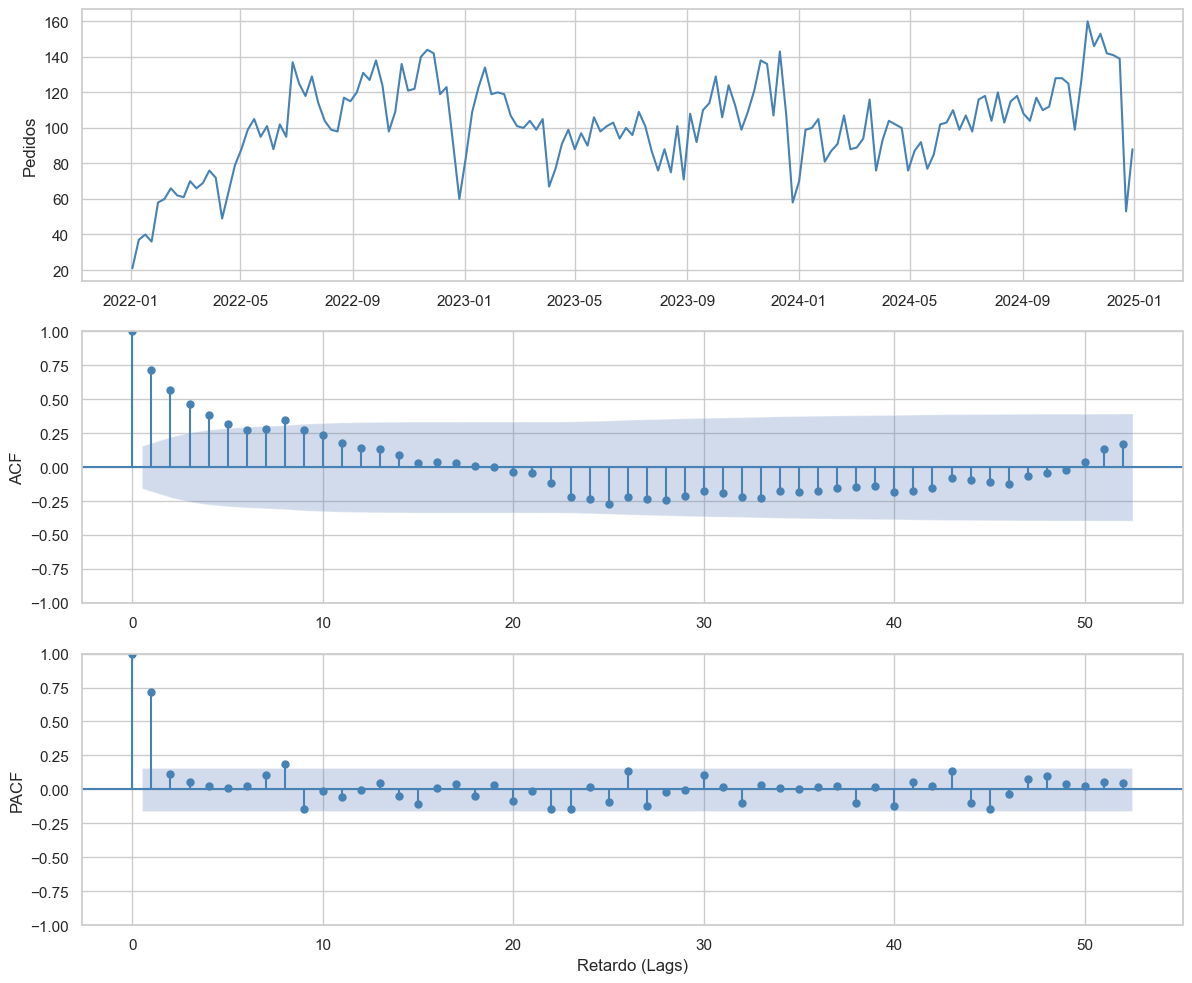

In [11]:
modelo = 'Global'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

Ante a presente tendencia, diferénciase a serie regularmente ($d = 1$):

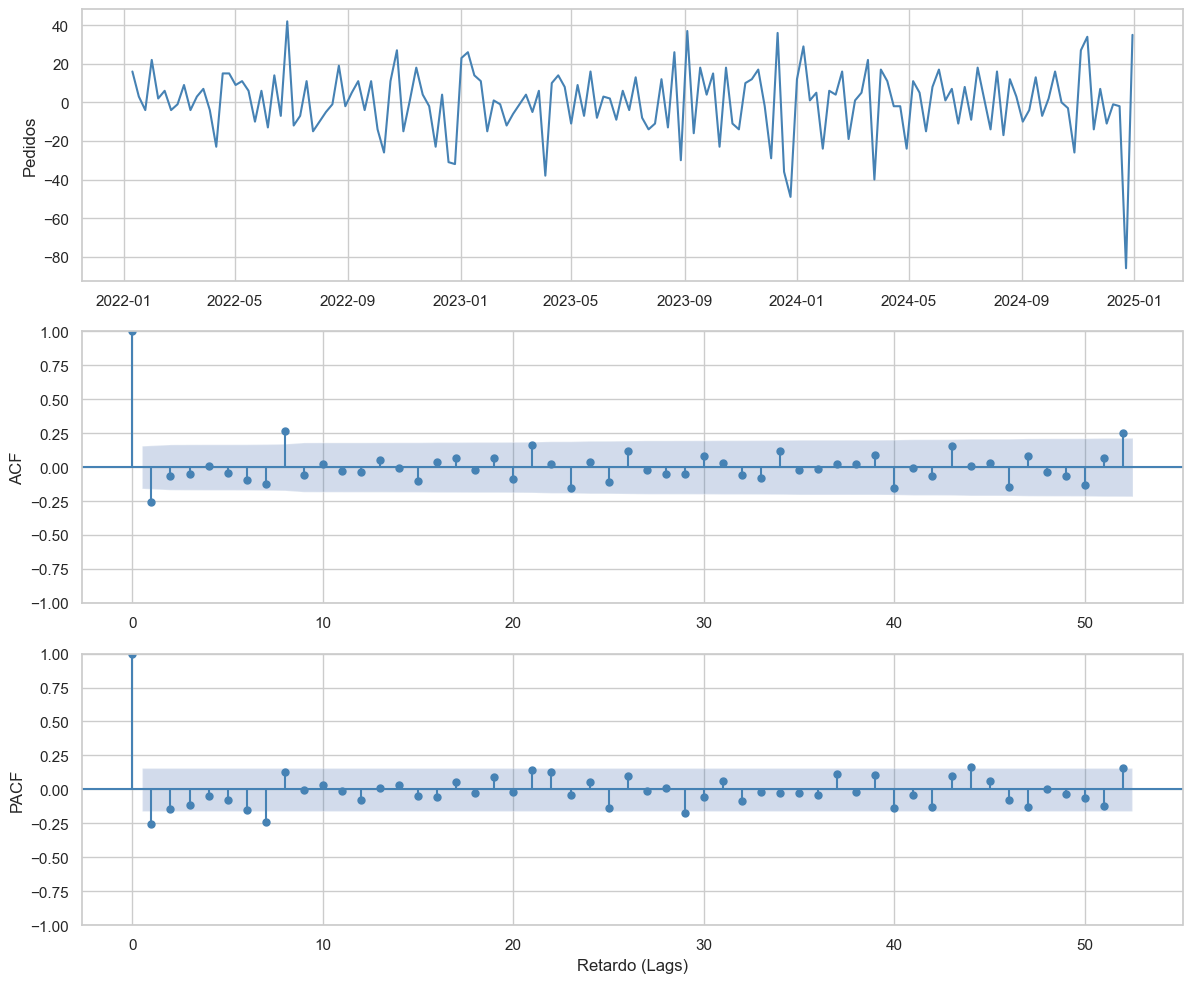

In [14]:
y_diff = datos_arima[modelo]['y_train'].diff().dropna()

ft.plot_identificacion_arima(
    y_diff,
    lags=52
)

Modelos suxeridos: ARIMA(1,1,0) ou  ARIMA(0,1,1).

#### Selección do modelo mediante AIC

In [15]:
modelo = 'Global'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1341.098, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1329.452, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1318.754, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1339.195, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1316.746, Time=0.22 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1319.119, Time=0.21 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1318.761, Time=0.33 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1317.332, Time=0.19 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1326.009, Time=0.18 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1318.152, Time=0.24 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1315.764, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1317.262, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1327.575, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AI

In [16]:
manual_order = (1, 1, 0)

model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')


model_manual.fit(datos_arima['Global']['y_train'], 
                X = datos_arima['Global']['X_train'])

best_order = manual_order

print(f"Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

Modelo ARIMA (1, 1, 0) axustado correctamente.
AIC = 1327.5752567704865


In [17]:
manual_order = (0, 1, 1)

model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')
model_manual.fit(datos_arima['Global']['y_train'], 
                X = datos_arima['Global']['X_train'])
best_order = manual_order
print(f"Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

Modelo ARIMA (0, 1, 1) axustado correctamente.
AIC = 1317.2624743963434


ARIMA(0,1,1) seleccionado.

In [18]:
print(model_manual.summary())
best_order = manual_order

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -653.631
Date:                Thu, 22 Jan 2026   AIC                           1317.262
Time:                        17:57:15   BIC                           1332.512
Sample:                    01-03-2022   HQIC                          1323.456
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_pre        19.3197      6.894      2.802      0.005       5.808      32.832
bf_peak       32.4756     16.318      1.990      0.047       0.493      64.458
bf_post       21.4005      5.397      3.966      0.0

#### Detección de atípicos (aditivos e innovativos)

In [19]:
modelo = 'Global'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y= datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    
    max_iter=10,    
    burn_in=3      
)
print(df_outliers)
print(X_train_con_outliers.head(5))

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order


 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2024-12-23 | t-stat: 4.72 > 3.59
   [Iter 2] Detectado: 2023-12-25 | t-stat: 3.75 > 3.59
   [Iter 3] Non se atoparon máis atípicos significativos (Max t: 3.15). Fin.
       fecha    t_stat  iter      tipo
0 2024-12-23 -4.716692     1  Negativo
1 2023-12-25 -3.752504     2  Negativo
            bf_pre  bf_peak  bf_post  outlier_20241223  outlier_20231225
semana                                                                  
2022-01-03       0        0        0                 0                 0
2022-01-10       0        0        0                 0                 0
2022-01-17       0        0        0                 0                 0
2022-01-24       0        0        0                 0                 0
2022-01-31       0        0        0                 0                 0


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Detéctanse dous outliers: 25/12/2023 e 23/12/2024.

#### Estimación ou axuste do modelo

In [21]:
modelo = 'Global'
print(f"Axustando modelo final SARIMAX{best_order} con {datos_arima['Global']['X_train_final'].shape[1]} variables exóxenas...")

# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],      
    order=datos_arima[modelo]['order'],         
    trend='n',               
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_axuste.fit(disp=False)

print(modelo_final.summary())

Axustando modelo final SARIMAX(0, 1, 1) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -630.563
Date:                Thu, 22 Jan 2026   AIC                           1275.126
Time:                        17:57:27   BIC                           1296.385
Sample:                    01-03-2022   HQIC                          1283.761
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              16.0029      5.913      2.706      0.007       4.414      27.592
bf_peak             27.2634     13.454      2

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Todos os coeficientes do modelo son significativos. 

#### Diagnose ou análise dos residuos

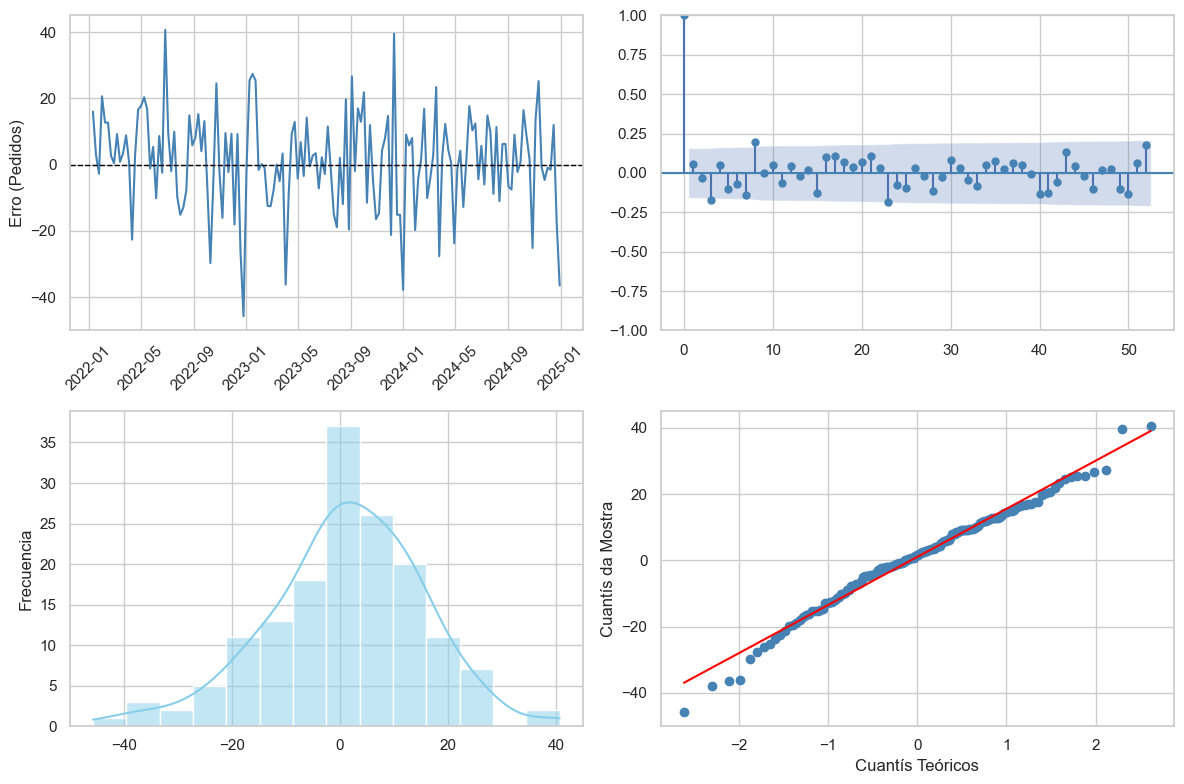


 --- INFORME ESTATÍSTICO ---
 Nesgo (Media=0):  p-value = 0.3675
  Normalidade (Shapiro): p-value = 0.1032
------------------------------------------------------------


In [23]:
ft.analizar_residuos_arima(modelo_final,lags=52)

In [24]:
print(modelo_final.summary())

                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -630.563
Date:                Thu, 22 Jan 2026   AIC                           1275.126
Time:                        17:57:42   BIC                           1296.385
Sample:                    01-03-2022   HQIC                          1283.761
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              16.0029      5.913      2.706      0.007       4.414      27.592
bf_peak             27.2634     13.454      2.026      0.043       0.893      53.633
bf_post             14.7547 

Normalidade no límite de rexeitamento (p-valor = $0.05$). O resto de hipóteses satisfanse.

#### Predicións

---VALIDACIÓN ROLLING WINDOW: Global ---
   Variables en modelo: 5
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (0, 1, 1)
 Iniciando Rolling Window ARIMAX (38 semanas)...


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

   > Semana 10/38: Pred=106.16


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

   > Semana 20/38: Pred=96.98


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

   > Semana 30/38: Pred=77.75


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


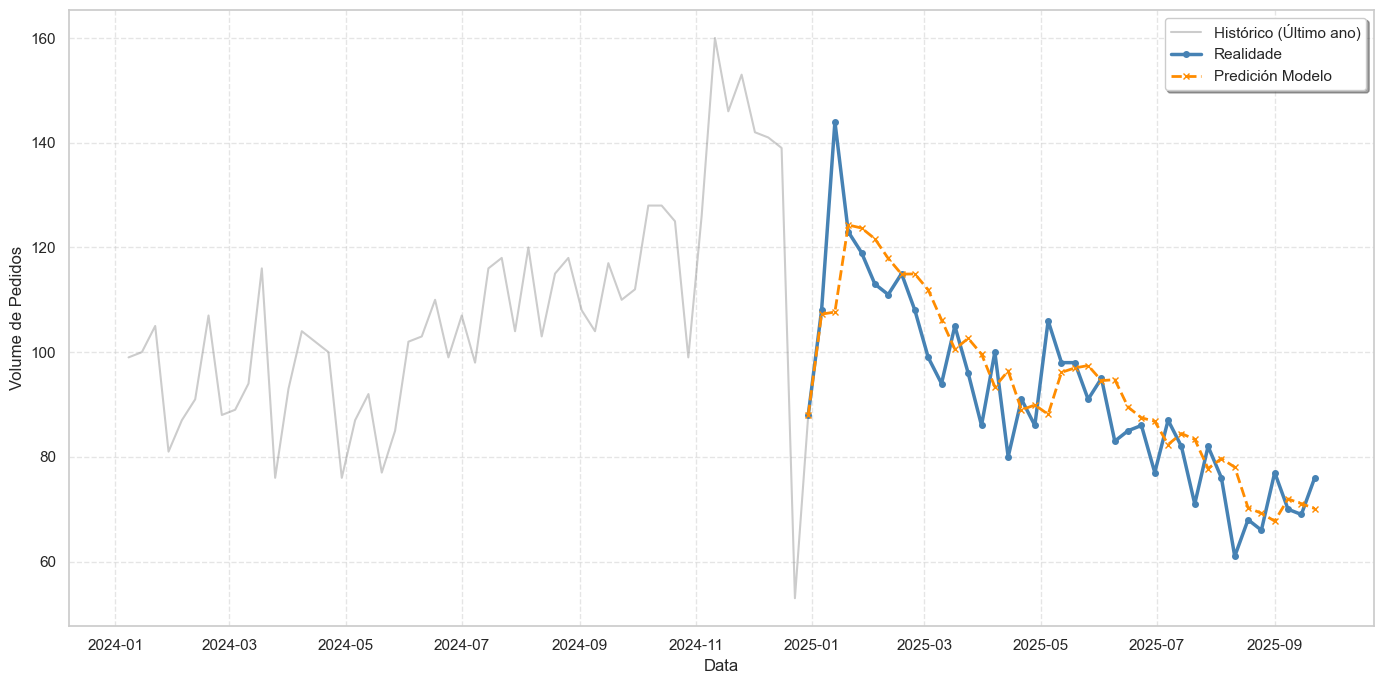

In [25]:
modelo = 'Global'
print(f"---VALIDACIÓN ROLLING WINDOW: {modelo} ---")
datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)
print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")
print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")
preds_rolling = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], 
    order=datos_arima[modelo]['order'],
    trend='n',             
    verbose=True           
)
datos_arima[modelo]['predicions'] = preds_rolling
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [26]:
modelo = 'Global'
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- AVALIACIÓN: Global (Rolling) ---
MAE:  7.07
RMSE: 9.84
MAPE: 7.81%
MASE: 0.54 (Non Estacional (m=1))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Información precisa para Prophet:

In [ ]:
modelo = 'Global'
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- GARDADO FINAL PARA PROPHET: {modelo} ---")

df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

export_para_prophet[modelo] = df_prophet

print(f"\n Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- 💾 GARDADO FINAL PARA PROPHET: Global ---
    Empaquetando datos de Global para Prophet...

 Datos exportados para Global.
   Dimensións: (195, 7)
   Columnas incluídas: ['semana', 'n_pedidos', 'bf_pre', 'bf_peak', 'bf_post', 'outlier_20241223', 'outlier_20231225']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  bf_pre  bf_peak  bf_post  outlier_20241223  \
190 2025-08-25         66       0        0        0                 0   
191 2025-09-01         77       0        0        0                 0   
192 2025-09-08         70       0        0        0                 0   
193 2025-09-15         69       0        0        0                 0   
194 2025-09-22         76       0        0        0                 0   

     outlier_20231225  
190                 0  
191                 0  
192                 0  
193                 0  
194                 0  


### Modelo por cluster

### Cluster 1

Clientes dos sectores de transporte, retail e electrónica.

In [28]:
df_cluster_1 = datos['Cluster 1'].set_index('semana')

#### Análise de intervención: Black Friday

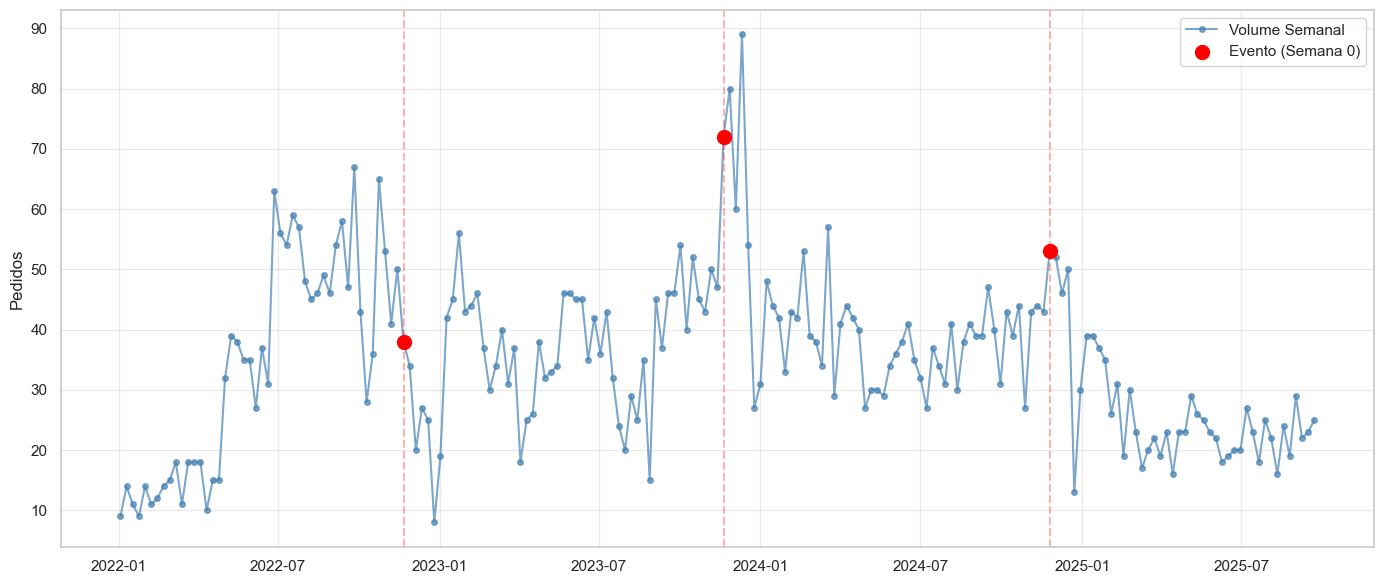

In [29]:
ft.plot_analisis_intervencion(df_input=df_cluster_1,
                              fechas_clave=fechas_bf)

Efecto do Black Friday icnluíndo a semana previa e a posterior.

In [30]:
modelo = 'Cluster 1'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_1)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=1, 
        weeks_post=1
    )
cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

#### Gráfico secuencial, fas e fap

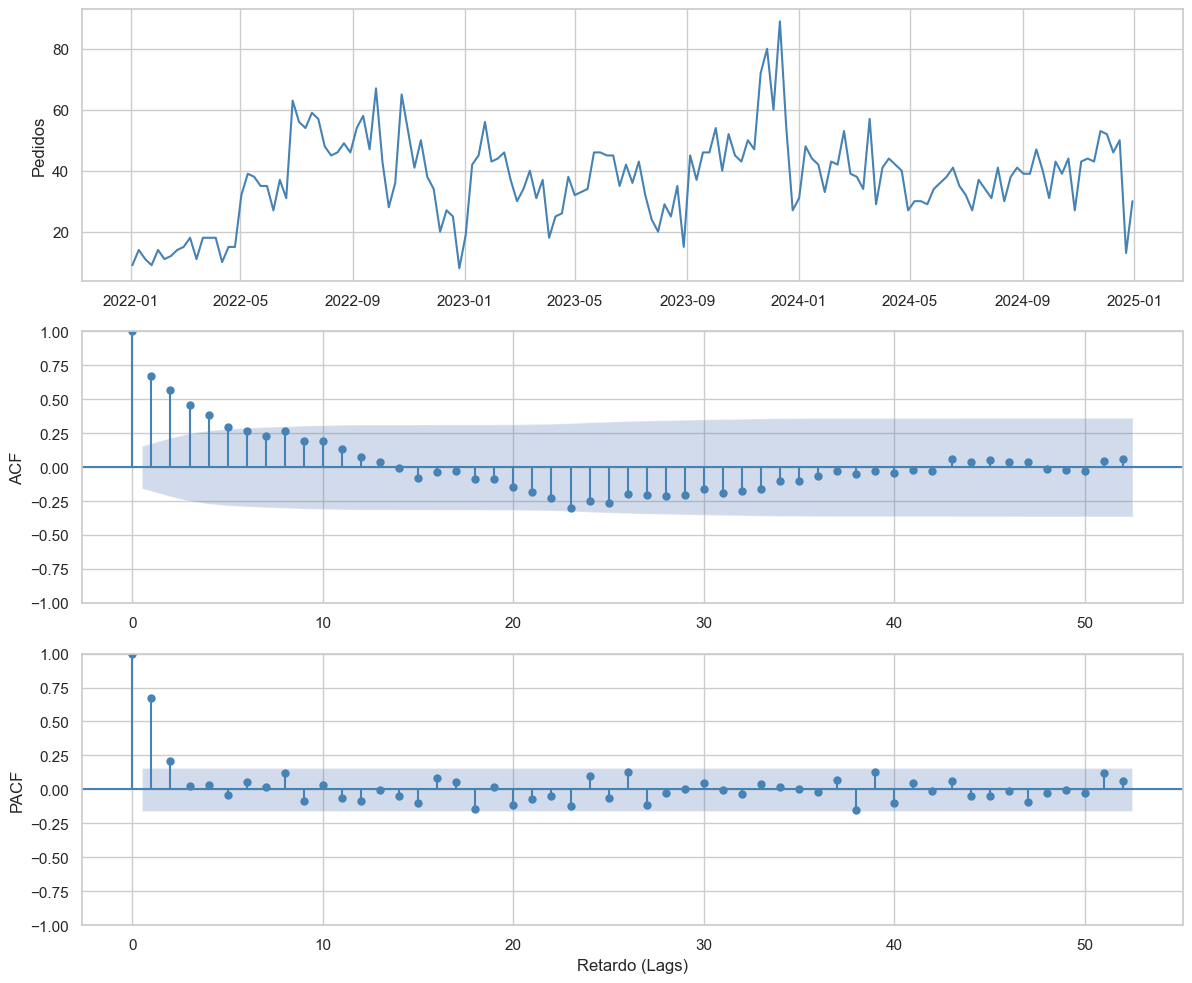

In [31]:
modelo = 'Cluster 1'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

Ante a tendencia positiva diferénciase regularmente ($d=1$).

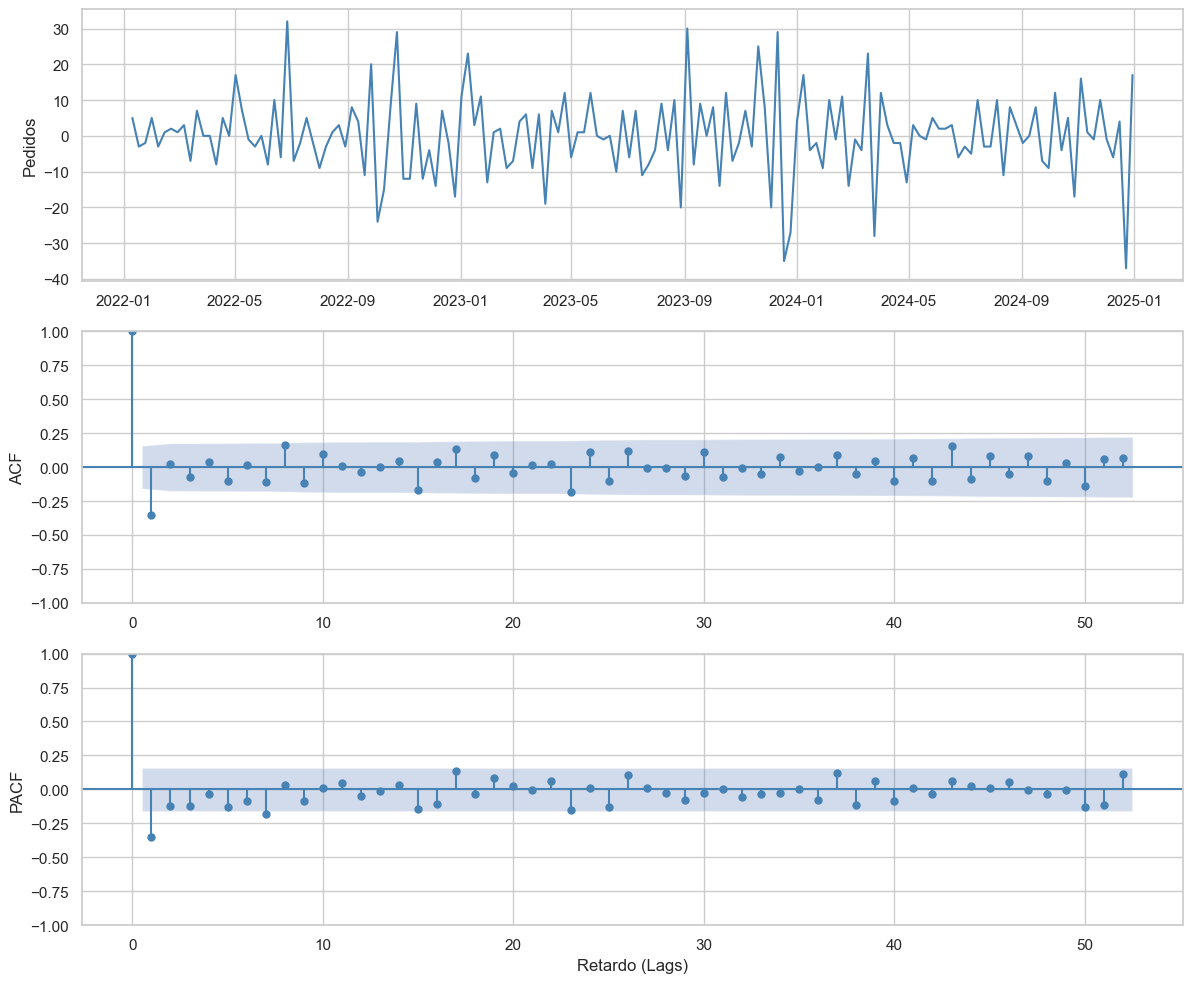

In [32]:
modelo = 'Cluster 1'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52
)

Modelos suxeridos: ARIMA(1,1,0) ou ARIMA(0,1,1).

#### Selección do modelo mediante AICc

Unha vez suxerido un modelo que poida explicar a nosa serie, imos seleccionar aquel que minimiza o AIC

In [33]:
modelo = 'Cluster 1'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1595.507, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1207.640, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1457.126, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1191.279, Time=0.11 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1190.914, Time=0.20 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=1188.695, Time=0.41 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=1190.399, Time=0.28 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=0.29 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=1183.129, Time=0.21 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=1181.260, Time=0.17 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1179.609, Time=0.13 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1184.724, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1182.615, Time=0.14 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=117

In [35]:
modelo = 'Cluster 1'
manual_order = (0, 1, 1)

model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (0, 1, 1) axustado correctamente.
AIC = 1174.9608715325155


In [36]:
modelo = 'Cluster 1'
manual_order = (1, 1, 0)

model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (1, 1, 0) axustado correctamente.
AIC = 1181.4020172939927


Obrigamos a que a selección automática diferencie regularmente ($d=1$)

In [37]:
modelo = 'Cluster 1'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d = 1
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1201.215, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1183.376, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1176.876, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1199.238, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1175.289, Time=0.19 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1176.259, Time=0.17 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1176.658, Time=0.19 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1182.632, Time=0.18 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1175.973, Time=0.29 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1173.562, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1174.961, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1181.402, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1174.6

Selecciónase o ARIMA(0,1,1)

In [38]:
manual_order = (0,1,1)
best_order = manual_order

#### Detección de atípicos (aditivos e innovativos)

Fagamos agora o contraste de detección de outliers do mesmo xeito que no caso anterior:

**Nota**: xa temos a función construída.

In [39]:
modelo = 'Cluster 1'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))

# Gardamos este novo X (que agora ten BF + Outliers) nun novo dicionario
# Este será o input para a seguinte fase (Refinado / Backward Elimination)
if 'datos_arima_final' not in locals():
    datos_arima_final = {}

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2023-12-25 | t-stat: 3.65 > 3.59
   [Iter 2] Non se atoparon máis atípicos significativos (Max t: 3.41). Fin.
       fecha    t_stat  iter      tipo
0 2023-12-25 -3.652071     1  Negativo
            bf_pre  bf_peak  bf_post  outlier_20231225
semana                                                
2022-01-03       0        0        0                 0
2022-01-10       0        0        0                 0
2022-01-17       0        0        0                 0
2022-01-24       0        0        0                 0
2022-01-31       0        0        0                 0


Atípico en 25/12/2023

#### Estimación ou axuste do modelo

Unha vez visto que non se detectan atípicos, axustemos o modelo e vexamos se todos os coeficientes son significativos ou non:

In [40]:
modelo = 'Cluster 1'
print(f"Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")


model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],      
    order = datos_arima[modelo]['order'],         
    trend ='n',               
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

Axustando modelo final SARIMAX(0, 1, 1) con 4 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -571.941
Date:                Thu, 22 Jan 2026   AIC                           1155.882
Time:                        18:00:54   BIC                           1174.104
Sample:                    01-03-2022   HQIC                          1163.284
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               2.3057     10.734      0.215      0.830     -18.733      23.344
bf_peak             10.4020      5.650      1

In [41]:
modelo = 'Cluster 1'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                   
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
 Variable 'bf_pre' eliminada correctamente das matrices.
 Reaxustando SARIMAX(0, 1, 1) coas 3 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -572.040
Date:                Thu, 22 Jan 2026   AIC                           1154.079
Time:                        18:01:13   BIC                           1169.264
Sample:                    01-03-2022   HQIC                          1160.247
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_peak              9.

Todos os coeficientes son significativos.

#### Diagnose ou análise dos residuos

Imos comprobar as hipóteses do modelo e ver así se o modelo axustado é válido. 
A hipótese fundamental a contrastar é a que esixe que as innovacións $\{a_t\}$ sexan ruído blanco, isto é:
1. Media cero
2. Homocedasticidade
3. Incorreladas

Graficamente:

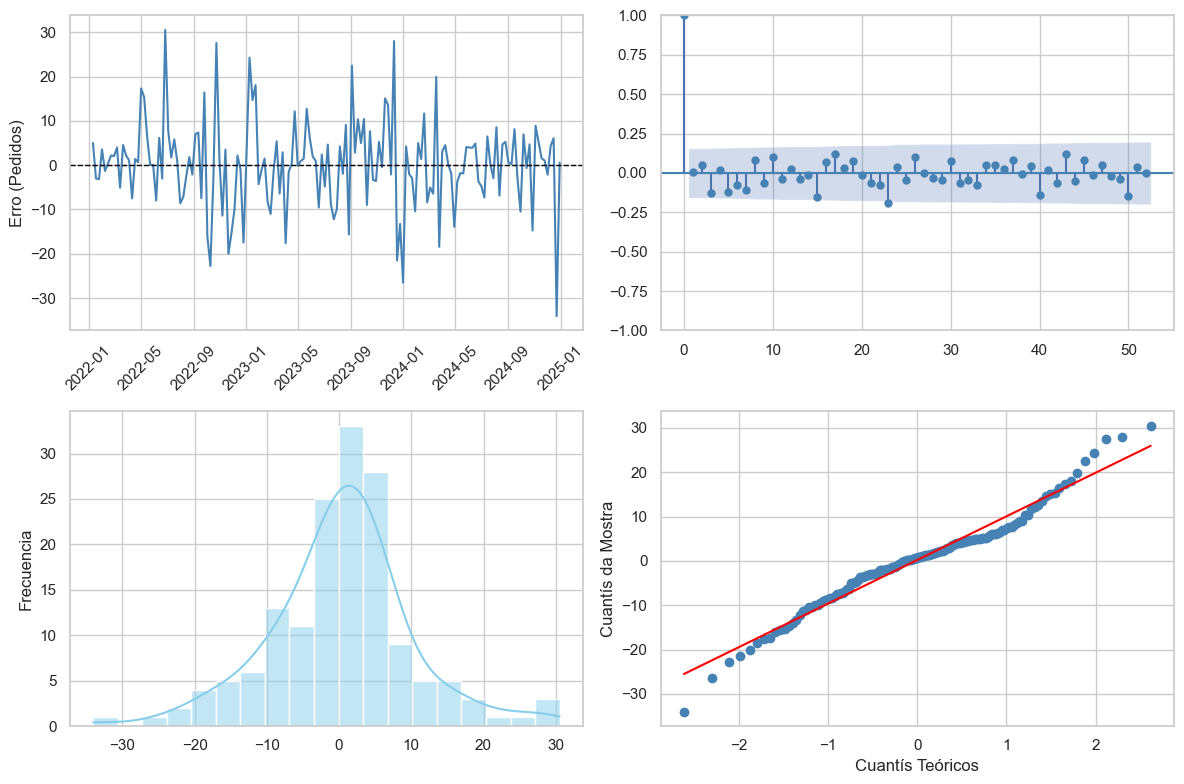


 --- INFORME ESTATÍSTICO ---
 Nesgo (Media=0):  p-value = 0.7717
  Normalidade (Shapiro): p-value = 0.0015
------------------------------------------------------------


In [42]:
ft.analizar_residuos_arima(modelo_final,lags=52)

Graficamente, no gráfico secuencial da serie non observamos problemas de heterocedasticidade. Nas fas mostrais tampouco vemos problemas de correlación. Ademáis, vendo o histograma e o QQ-plot, pode verse unha distribución con certa asimetría polo que é posible que falle a normalidade dos residuos.

Debemos facer os contrastes numéricos para asegurarnos do cumprimento das hipóteses do modelo.

In [43]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -572.040
Date:                Thu, 22 Jan 2026   AIC                           1154.079
Time:                        18:01:26   BIC                           1169.264
Sample:                    01-03-2022   HQIC                          1160.247
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_peak              9.7058      3.692      2.629      0.009       2.470      16.941
bf_post             11.3606      4.460      2.547      0.011       2.620      20.101
outlier_20231225   -24.0962      5.343     -4.510      0.000     -34.568     -13.625
ma.L1               -0.4818      0.069     -7.032      0.000      -0.616      -0.348
sigma2              98.5746      8.826     11.168      0.000      81.275     115.874
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                13.61
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               0.62   Skew:                            -0.02
Prob(H) (two-sided):                  0.09   Kurtosis:                         4.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Modelo válido con innovacións non gaussianas.

#### Predicións

---  VALIDACIÓN ROLLING WINDOW: Cluster 1 ---
   Variables en modelo: 3
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (0, 1, 1)
 Iniciando Rolling Window ARIMAX (38 semanas)...
   > Semana 10/38: Pred=25.19
   > Semana 20/38: Pred=25.79
   > Semana 30/38: Pred=20.57


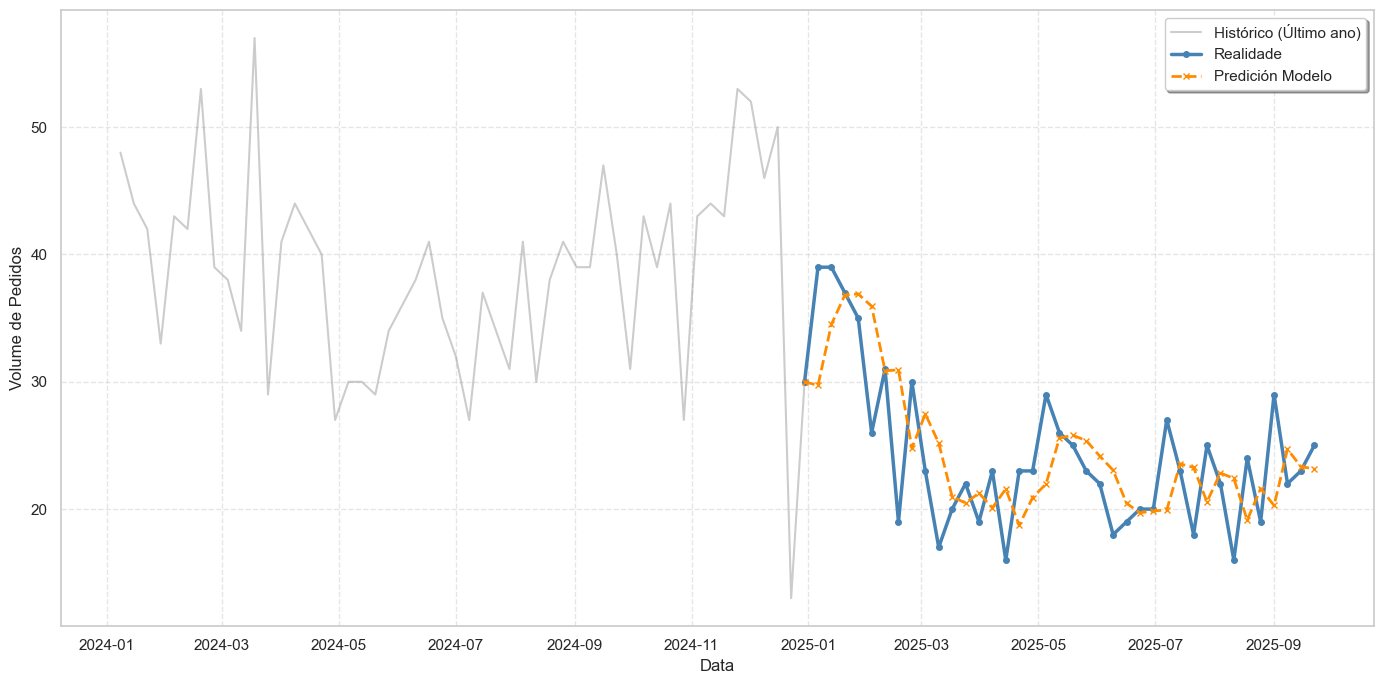

In [45]:
modelo = 'Cluster 1'
print(f"---  VALIDACIÓN ROLLING WINDOW: {modelo} ---")

# 2. ALIÑACIÓN DE COLUMNAS (CRÍTICO)
# X_train ten columnas de outliers que X_test non ten.
# Creamos esas columnas en X_test e enchémolas con 0 (o futuro non ten eses erros pasados)
datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

# 4. EXECUCIÓN DO ROLLING WINDOW

preds_rolling = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], 
    order=datos_arima[modelo]['order'],
    trend='n',             
    verbose=True          
)
# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling
# 6. REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [ ]:
modelo = 'Cluster 1'
# 5. CÁLCULO DE MÉTRICAS
# m=1 porque non hai estacionalidade no modelo 
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- AVALIACIÓN: Cluster 1 (Rolling) ---
MAE:  3.70
RMSE: 4.82
MAPE: 16.28%
MASE: 0.45 (Non Estacional (m=1))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Resultados practicamente idénticos aos datos orixinais.

Gardamos a información de atípicos e análise de intervención para empregar no Prophet:

In [47]:
modelo = 'Cluster 1'
# 1. Inicializamos o dicionario mestre (se non existe xa)
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- GARDADO FINAL PARA PROPHET: {modelo} ---")

# 3. Chamamos á función de empaquetado
df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

# 4. Gardamos no dicionario
export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- GARDADO FINAL PARA PROPHET: Cluster 1 ---
    Empaquetando datos de Cluster 1 para Prophet...

 Datos exportados para Cluster 1.
   Dimensións: (195, 5)
   Columnas incluídas: ['semana', 'n_pedidos', 'bf_peak', 'bf_post', 'outlier_20231225']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  bf_peak  bf_post  outlier_20231225
190 2025-08-25         19        0        0                 0
191 2025-09-01         29        0        0                 0
192 2025-09-08         22        0        0                 0
193 2025-09-15         23        0        0                 0
194 2025-09-22         25        0        0                 0


### Cluster 2

Pasamos agora a axustar un modelo ARIMA para o cluster formado polos clientes de paquetería e froita.

In [48]:
df_cluster_2 = datos['Cluster 2'].set_index('semana')

#### Análise de intervención: Black Friday

Novamente repetimos a análise do impacto do Black Friday, agora sobre os clientes do segundo cluster.

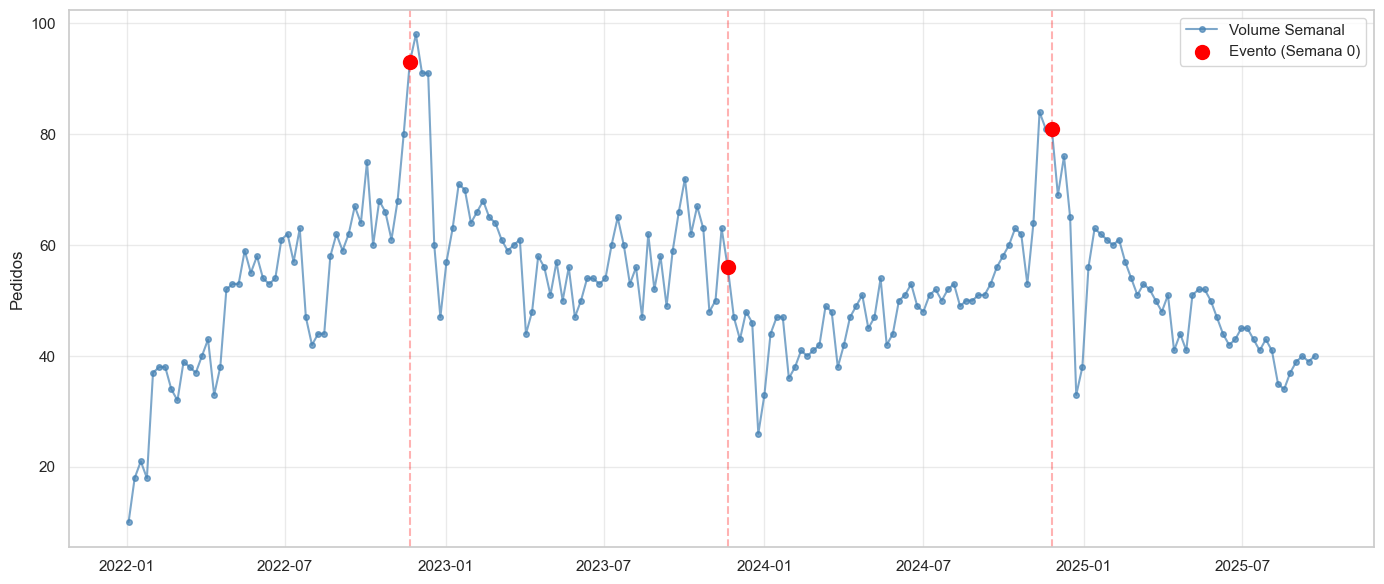

In [49]:
ft.plot_analisis_intervencion(df_input=df_cluster_2,
                              fechas_clave=fechas_bf)

Graficamente, vemos como o efecto previo do B-F se extende pricipalmente ás dúas semanas anteriores (sobre todo no 2022 e 2024). Ademáis, no 2022 observamos como o pico se exntende unha semana e despois cae, mentres uqe no 2023 e 2024 cae na seguinte semana (no 2023 en particular é maior o efecto na semana previa ca na propia semana do evento). 

Así, decidimos modelar o efecto do B-F con 3 variables dummys. Aprimeira plasmará o efecto das dúas semanas previas, a segunda a da propia semana e a última o efecto da semana posterior.

In [50]:
modelo = 'Cluster 2'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_2)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=2, 
        weeks_post=1
    )

cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

##### Gráfico secuencial, fas e fap

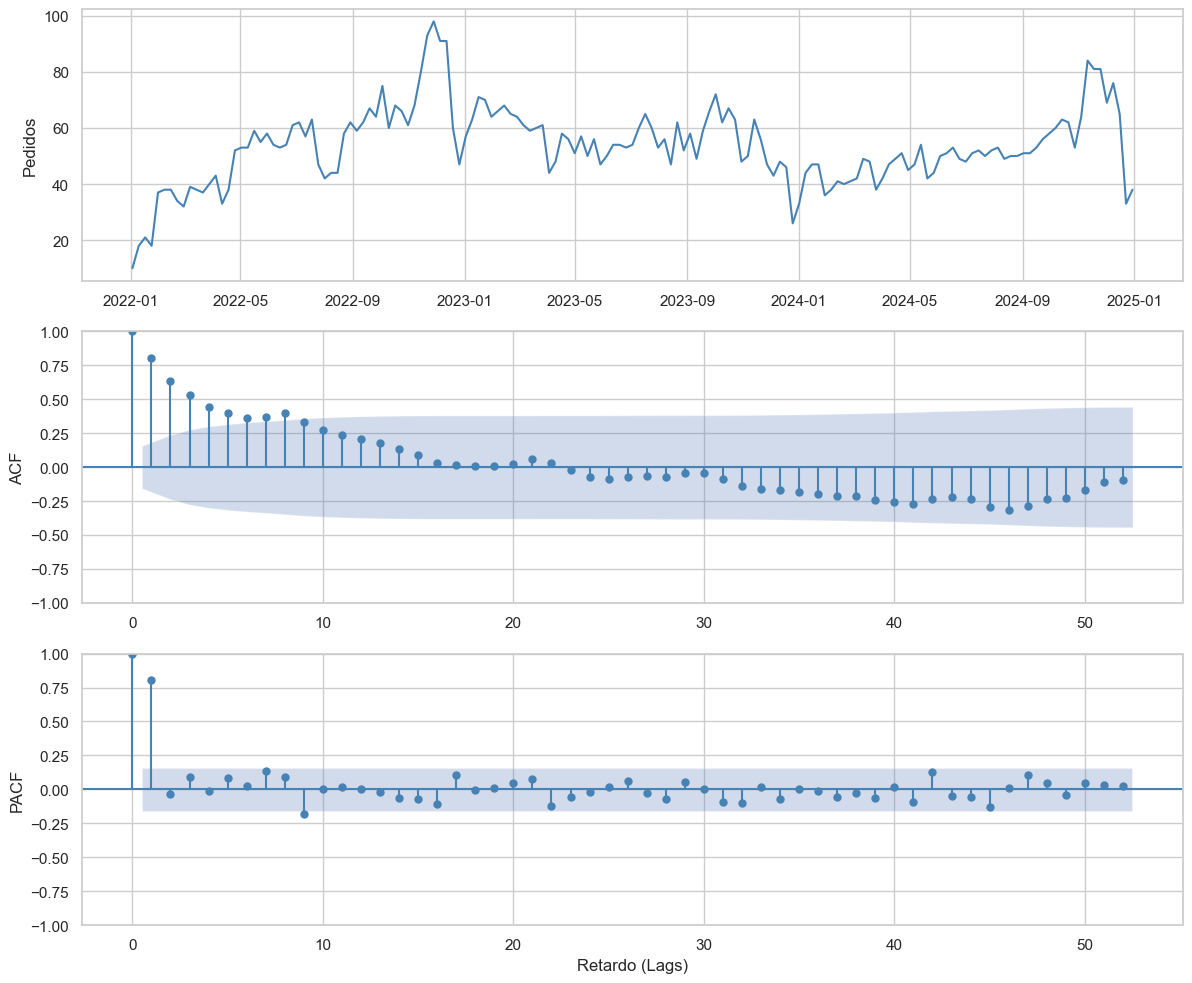

In [51]:
modelo = 'Cluster 2'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

Observando o gráfico secuencial e a fas mostral, podemos intuir a presenza de tendencia. Polo tanto, podemos pensar en repetir os gráficos unha vez diferenciada a serie.

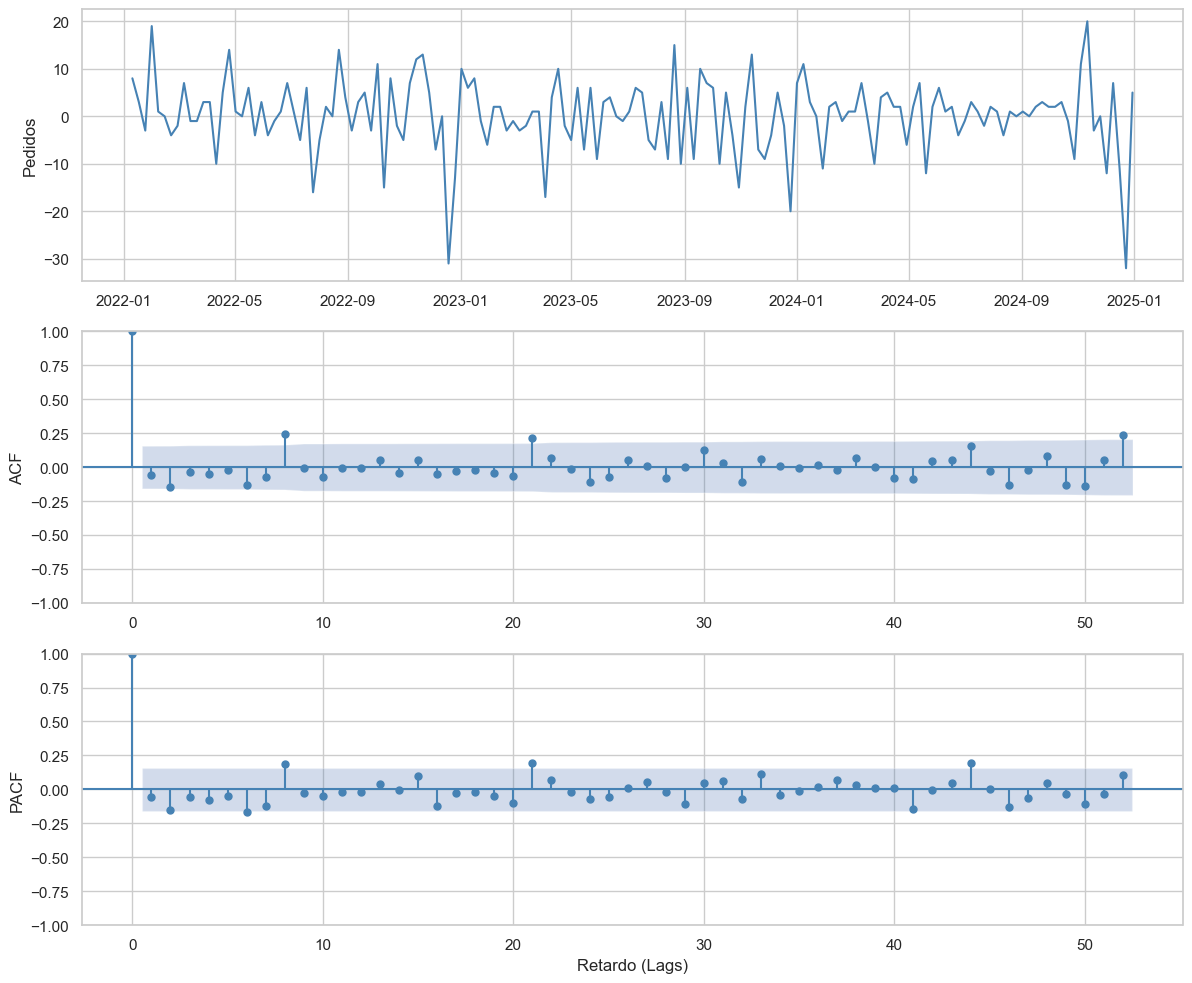

In [52]:
modelo = 'Cluster 2'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52
)

Unha vez diferenciada a serie, non se observan problemas de estacionalidade nin heterocedasticidade. Ademáis, observando os gráficos das fas e fap mostrais podemos suxerir un ARMA(0,0) para a serie diferenciada. Daquela, para a serie orixinal poderiamos suxerir un ARIMA(0,1,0)

#### Selección do modelo mediante AICc

In [53]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1691.548, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1094.293, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1095.594, Time=0.15 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1095.255, Time=0.25 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.19 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1085.674, Time=0.22 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1249.817, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1087.708, Time=0.23 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1087.263, Time=0.23 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1155.288, Time=0.15 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.21 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 1.890 seconds
                               SARIMAX Resul

In [54]:
modelo = 'Cluster 2'

manual_order = (0, 1, 0)


model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')


model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (0, 1, 0) axustado correctamente.
AIC = 1083.060947087964


Vemos daquela como o modelo suxerido pola interpretación gráica sería mellor ao modelo axustado automaticamente. (Que a función auto_arima non probe modelos con d=1 débese a que non rexeita a estacionariedade da serie de partida. Sinalemos que graficamente tampouco é que se observase unha gran tendencia.). Obligamos entón ao criterio automático a avaliar os modelos con d=1.

In [55]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d=1
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1084.974, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1086.185, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1085.784, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1083.061, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.376 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -537.530
Date:                Thu, 22 Jan 2026   AIC                           1083.061
Time:                        18:03:14   BIC                           1095.260
Sample:                    01-03-2022   HQIC                          1088.016
                         

In [56]:
best_order = modelo_global.order

#### Detección de atípicos (aditivos e innovativos)

Pasamos agora á detección de outliers mediante a función que definimos no primeiro modelo axustado:

In [57]:
modelo = 'Cluster 2'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))


datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2024-12-23 | t-stat: 4.19 > 3.59
   [Iter 2] Detectado: 2022-12-19 | t-stat: 4.23 > 3.59
   [Iter 3] Non se atoparon máis atípicos significativos (Max t: 3.03). Fin.
       fecha    t_stat  iter      tipo
0 2024-12-23 -4.193103     1  Negativo
1 2022-12-19 -4.227691     2  Negativo
            bf_pre  bf_peak  bf_post  outlier_20241223  outlier_20221219
semana                                                                  
2022-01-03       0        0        0                 0                 0
2022-01-10       0        0        0                 0                 0
2022-01-17       0        0        0                 0                 0
2022-01-24       0        0        0                 0                 0
2022-01-31       0        0        0                 0                 0


Atípicos en 19/12/2022 e 23/12/2024.

#### Estimación ou axuste do modelo

Axustamos o modelo resultante e vemos se os seus parámetros son significativos ou non.

In [58]:
modelo = 'Cluster 2'
print(f"Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       
    order = datos_arima[modelo]['order'],        
    trend ='n',                
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Adestramos
modelo_final = model_axuste.fit(disp=False)

#  Mostramos a táboa de significación
print(modelo_final.summary())

Axustando modelo final SARIMAX(0, 1, 0) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -526.303
Date:                Thu, 22 Jan 2026   AIC                           1064.607
Time:                        18:04:04   BIC                           1082.867
Sample:                    01-03-2022   HQIC                          1072.024
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               8.4167      3.445      2.443      0.015       1.664      15.169
bf_peak              9.1667      4.067      2

In [59]:
modelo = 'Cluster 2'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_post'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_post'...
 Variable 'bf_post' eliminada correctamente das matrices.
 Reaxustando SARIMAX(0, 1, 0) coas 4 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -526.559
Date:                Thu, 22 Jan 2026   AIC                           1063.118
Time:                        18:04:24   BIC                           1078.335
Sample:                    01-03-2022   HQIC                          1069.299
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               

Todos os coeficientes significativos.

#### Diagnose ou análise dos residuos

Graficamente:

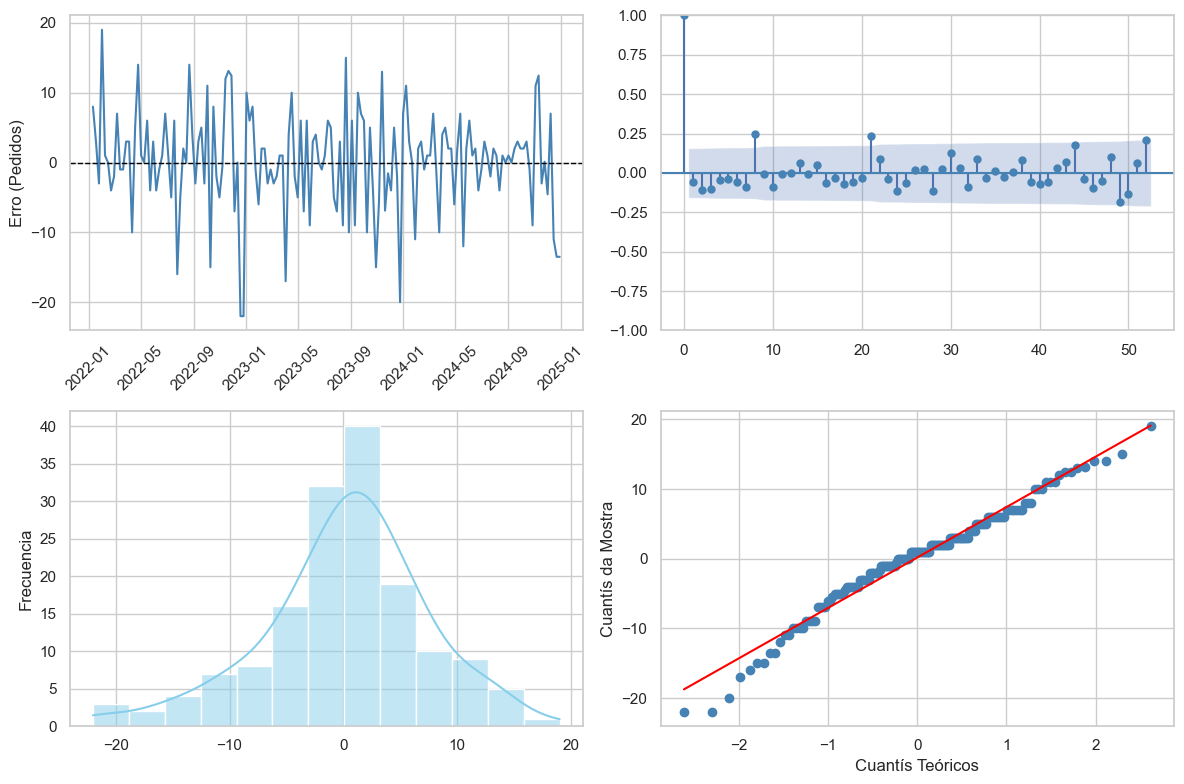


 --- INFORME ESTATÍSTICO ---
 Nesgo (Media=0):  p-value = 0.7578
  Normalidade (Shapiro): p-value = 0.0057
------------------------------------------------------------


In [60]:
ft.analizar_residuos_arima(modelo_final,lags=52)

Graficamente non asemella que teñamos problemas nin de heterocedasticidade, nin correlación. Ademáis, parece tamén que os residuos teñen media 0. Porén a normalidade dos residuos seguramente non se vaia a cumprir. Fagamos os contrastes pertinentes:

In [61]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -526.559
Date:                Thu, 22 Jan 2026   AIC                           1063.118
Time:                        18:04:43   BIC                           1078.335
Sample:                    01-03-2022   HQIC                          1069.299
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               7.5556      3.100      2.437      0.015       1.480      13.632
bf_peak              7.4444      3.131      2.378      0.017       1.308      13.581
outlier_20241223   -18.5000      2.738     -6.757      0.000     -23.866     -13.134
outlier_20221219    -9.0000      1.680     -5.357      0.000     -12.293      -5.707
sigma2              52.2709      5.078     10.294      0.000      42.318      62.224
===================================================================================
Ljung-Box (L1) (Q):                   0.57   Jarque-Bera (JB):                 9.82
Prob(Q):                              0.45   Prob(JB):                         0.01
Heteroskedasticity (H):               0.49   Skew:                            -0.48
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Cuidado** non se cumpre a hipótese da homocedasticidade. Temos un p-valor no test de Homocedasticidade de 0.01 < 0.05, co cal debemos reaxustar o modelo.

#### Corrección da heterocedasticidade

Aplicaremos unha transformación logarítmica aos nosos datos e repetiremos o procedemento.

In [62]:
modelo = 'Cluster 2'
datos_arima[modelo]['y_train'] = np.log(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.log(datos_arima[modelo]['y_test'])

**Selección das ordes (p,d,q)**

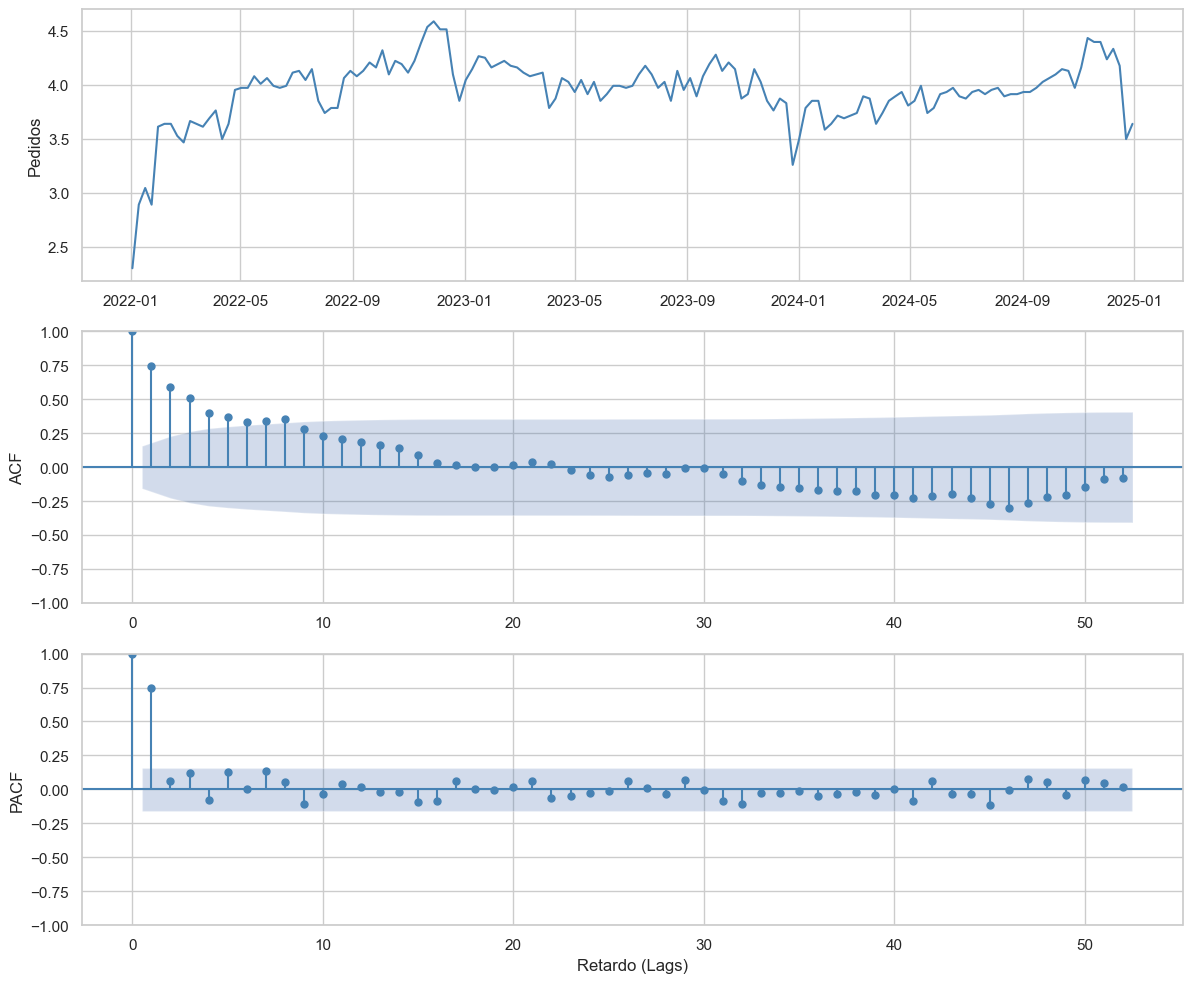

In [64]:
modelo = 'Cluster 2'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

Seguimos vendo problemas de tendencia. Diferenciemos a serie transformada.

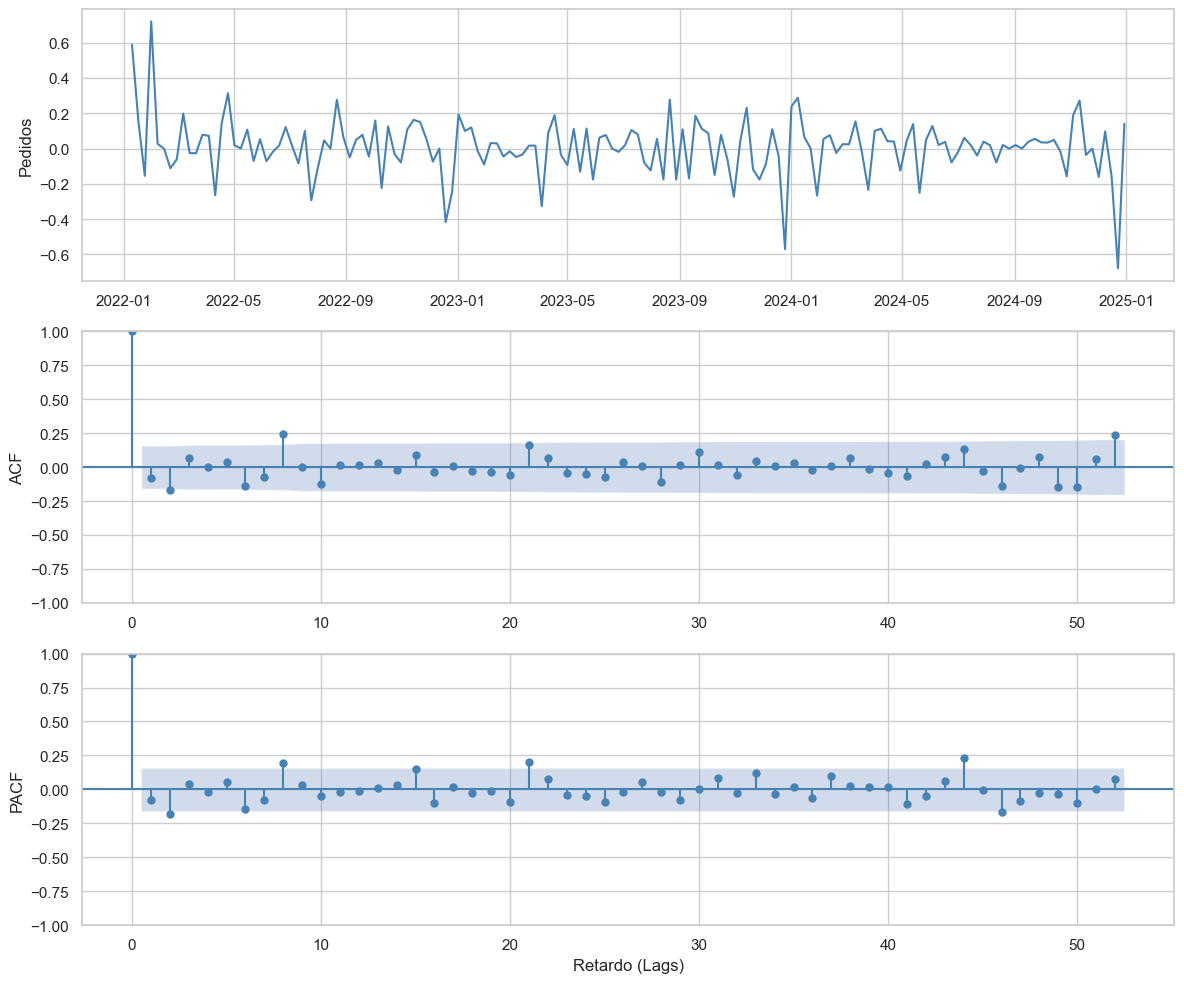

In [65]:
modelo = 'Cluster 2'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52
)

Para a serie do log diferenciada podemos suxerir un ARMA(0,0). Co cal a serie tranformada pode vir explicada por un ARIMA(0,1,0).

**Selección automática**

In [66]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=870.676, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-112.321, Time=0.11 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-109.416, Time=0.21 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-116.550, Time=0.37 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.28 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-111.362, Time=0.27 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-114.958, Time=0.29 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.31 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-113.253, Time=0.38 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-110.174, Time=0.27 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 2.768 seconds
                               SARIMAX Results    

O mellor modelo segundo o AIC sería un ARIMA(1,0,2). Novamente sucede que a función auto_arima non avalía modelos con d=1. Probemos manuealmente o ARIMA(0,1,0) e comparemos o AIC co suposto óptimo.

In [67]:
modelo = 'Cluster 2'

manual_order = (0, 1, 2)


model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')


model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])


best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (0, 1, 2) axustado correctamente.
AIC = -123.72606435644605


In [68]:
modelo = 'Cluster 2'

manual_order = (2, 1, 0)


model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')


model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])


best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (2, 1, 0) axustado correctamente.
AIC = -123.91931479139691


In [69]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d = 1
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-117.690, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-117.066, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-117.917, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-119.248, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-119.176, Time=0.22 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.492 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                  63.624
Date:                Thu, 22 Jan 2026   AIC                           -119.248
Time:                        18:05:43   BIC                           -107.049
Sample:                    01-03-2022   HQIC                          -114.294
                    

Non proba máis aló do ARIMA(1,1,1). Obrígase a partir de $p=q=2$:

In [70]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d = 1,
    start_p = 2
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-122.695, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-117.690, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-117.066, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-117.917, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-119.248, Time=0.05 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-120.697, Time=0.22 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-120.697, Time=0.28 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-119.176, Time=0.18 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-118.699, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-123.919, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-118.580, Time=0.04 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-121.920, Time=0.10 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-121.921, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-

In [71]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d = 1,
    start_q = 2
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-122.670, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-117.690, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-117.066, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-117.917, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-119.248, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-120.941, Time=0.21 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-120.947, Time=0.21 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-119.176, Time=0.17 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-119.343, Time=0.27 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-123.726, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-119.377, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-122.079, Time=0.13 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=-122.103, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-

Daquela o mellor modelo sería un ARIMA(2,1,0) con AIC = -119.33. Como o modelo suxerido graficamente (ARIMA(0,1,0)) empeora en máis de dúas unidades o AIC óptimo, quedamos co modelo proposto polo criterio automático.

In [72]:
best_order = (2,1,0)

**Detección de atípicos**

In [73]:
modelo = 'Cluster 2'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2022-01-31 | t-stat: 4.89 > 3.59
   [Iter 2] Detectado: 2024-12-23 | t-stat: 4.34 > 3.59
   [Iter 3] Detectado: 2023-12-25 | t-stat: 3.97 > 3.59
   [Iter 4] Non se atoparon máis atípicos significativos (Max t: 3.16). Fin.
       fecha    t_stat  iter      tipo
0 2022-01-31  4.891930     1  Positivo
1 2024-12-23 -4.339101     2  Negativo
2 2023-12-25 -3.967222     3  Negativo
            bf_pre  bf_peak  bf_post  outlier_20220131  outlier_20241223  \
semana                                                                     
2022-01-03       0        0        0                 0                 0   
2022-01-10       0        0        0                 0                 0   
2022-01-17       0        0        0                 0                 0   
2022-01-24       0        0        0                 0                 0   
2022-01-31       0        0        0                 1                 0   

            outli

Tres outliers: 31/01/2022, 23/12/2024 e 25/12/2023.

**Estimación ou axuste do modelo**

In [74]:
modelo = 'Cluster 2'
print(f" Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

 Axustando modelo final SARIMAX(2, 1, 0) con 6 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  94.478
Date:                Thu, 22 Jan 2026   AIC                           -170.956
Time:                        18:06:05   BIC                           -143.623
Sample:                    01-03-2022   HQIC                          -159.853
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0.1222      0.086      1.417      0.156      -0.047       0.291
bf_peak              0.1541      0.088      

Vemos como o coeficiente $\varphi_1$ non é significativo. Debemos fixalo a 0 reaxustar o modelo:

In [75]:
modelo = 'Cluster 2'
print(f" Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final = model_axuste.fit_constrained(constraints)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

 Axustando modelo final SARIMAX(2, 1, 0) con 6 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  94.220
Date:                Thu, 22 Jan 2026   AIC                           -172.441
Time:                        18:06:12   BIC                           -148.145
Sample:                    01-03-2022   HQIC                          -162.572
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0.1215      0.095      1.273      0.203      -0.066       0.309
bf_peak              0.1482      0.091      

In [ ]:
modelo = 'Cluster 2'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_post'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

constraints = {'ar.L1': 0}

# Adestramos
modelo_final = model_refinado.fit_constrained(constraints)

# Mostramos a táboa de significación
print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_post'...
 Variable 'bf_post' eliminada correctamente das matrices.
 Reaxustando SARIMAX(2, 1, 0) coas 5 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  93.634
Date:                Thu, 22 Jan 2026   AIC                           -173.269
Time:                        18:06:36   BIC                           -152.010
Sample:                    01-03-2022   HQIC                          -164.634
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               

In [77]:
modelo = 'Cluster 2'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final =  model_refinado.fit_constrained(constraints)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
 Variable 'bf_pre' eliminada correctamente das matrices.
 Reaxustando SARIMAX(2, 1, 0) coas 4 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  92.334
Date:                Thu, 22 Jan 2026   AIC                           -172.667
Time:                        18:07:39   BIC                           -154.446
Sample:                    01-03-2022   HQIC                          -165.266
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_peak              0.

In [78]:
modelo = 'Cluster 2'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_peak'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_peak'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final =  model_refinado.fit_constrained(constraints)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_peak'...
 Variable 'bf_peak' eliminada correctamente das matrices.
 Reaxustando SARIMAX(2, 1, 0) coas 3 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  91.818
Date:                Thu, 22 Jan 2026   AIC                           -173.636
Time:                        18:07:51   BIC                           -158.451
Sample:                    01-03-2022   HQIC                          -167.468
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220131     

Todos os termos significativos. 

**Diagnose ou validación do modelo**

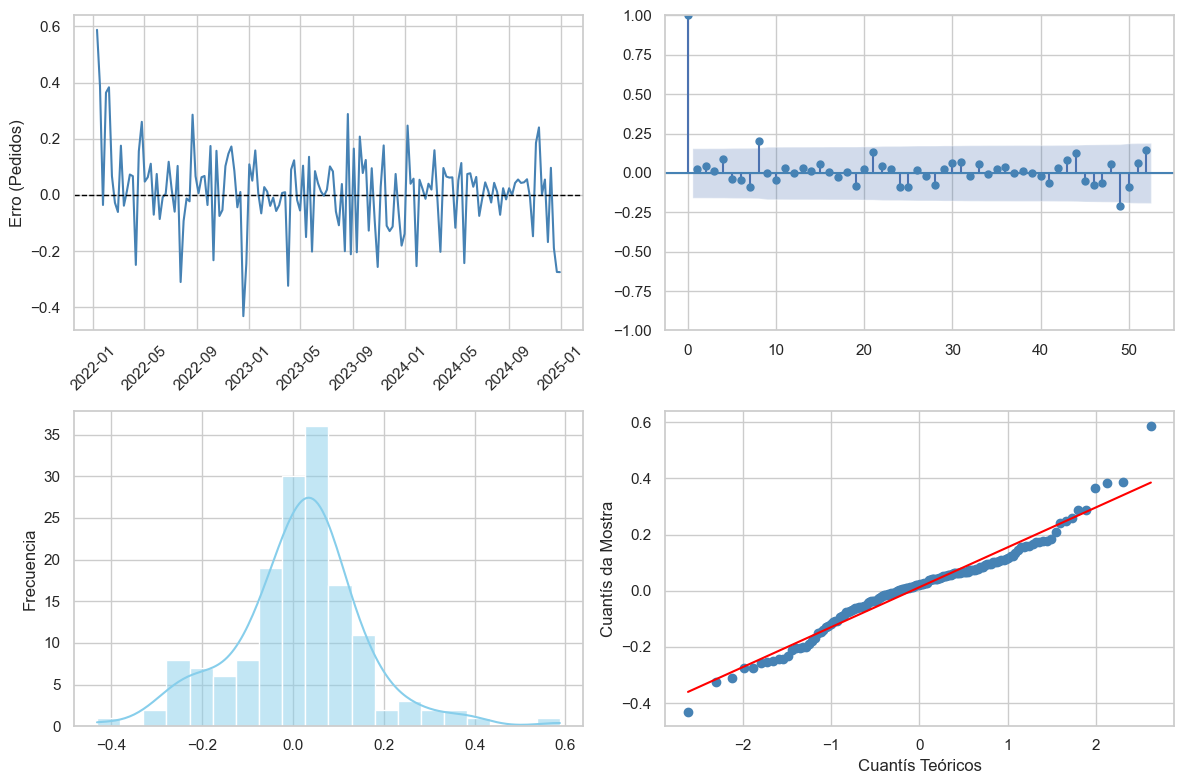


 --- INFORME ESTATÍSTICO ---
 Nesgo (Media=0):  p-value = 0.2808
  Normalidade (Shapiro): p-value = 0.0005
------------------------------------------------------------


In [79]:
ft.analizar_residuos_arima(modelo_final,lags=52)

O problema co primeiro residuo e pola propia construción do modelo (diferenciado) que non detecta dito dato como atípico polo algoritmo interno (non hai que preocuparse).

In [80]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  91.818
Date:                Thu, 22 Jan 2026   AIC                           -173.636
Time:                        18:08:03   BIC                           -158.451
Sample:                    01-03-2022   HQIC                          -167.468
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220131     0.3876      0.037     10.604      0.000       0.316       0.459
outlier_20241223    -0.3843      0.047     -8.134      0.000      -0.477      -0.292
outlier_20231225    -0.3682      0.076     -4.817      0.000      -0.518      -0.218
ar.L1 (fixed)             0        nan        nan        nan         nan         nan
ar.L2               -0.2015      0.092     -2.191      0.028      -0.382      -0.021
sigma2               0.0178      0.002     10.199      0.000       0.014       0.021
===================================================================================
Ljung-Box (L1) (Q):                   0.25   Jarque-Bera (JB):                 6.92
Prob(Q):                              0.62   Prob(JB):                         0.03
Heteroskedasticity (H):               0.53   Skew:                            -0.34
Prob(H) (two-sided):                  0.03   Kurtosis:                         3.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Aínda que p-valor $= 0.003$, graficamente non se ben problemas de heterocedasticidade.

#### Predicións

Moi impostante sinalar que, como axustamos o modelo á serie transformada (log), debemos facer as predicións con estos datos e, para poder interpretar e avaliar as métricas, transformar as predicións mediante a función inversa (exp):

---  VALIDACIÓN ROLLING WINDOW: Cluster 2 ---
   Variables en modelo: 3
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (2, 1, 0)
 Iniciando Rolling Window ARIMAX (38 semanas)...
   > Semana 10/38: Pred=3.95
   > Semana 20/38: Pred=3.90
   > Semana 30/38: Pred=3.73


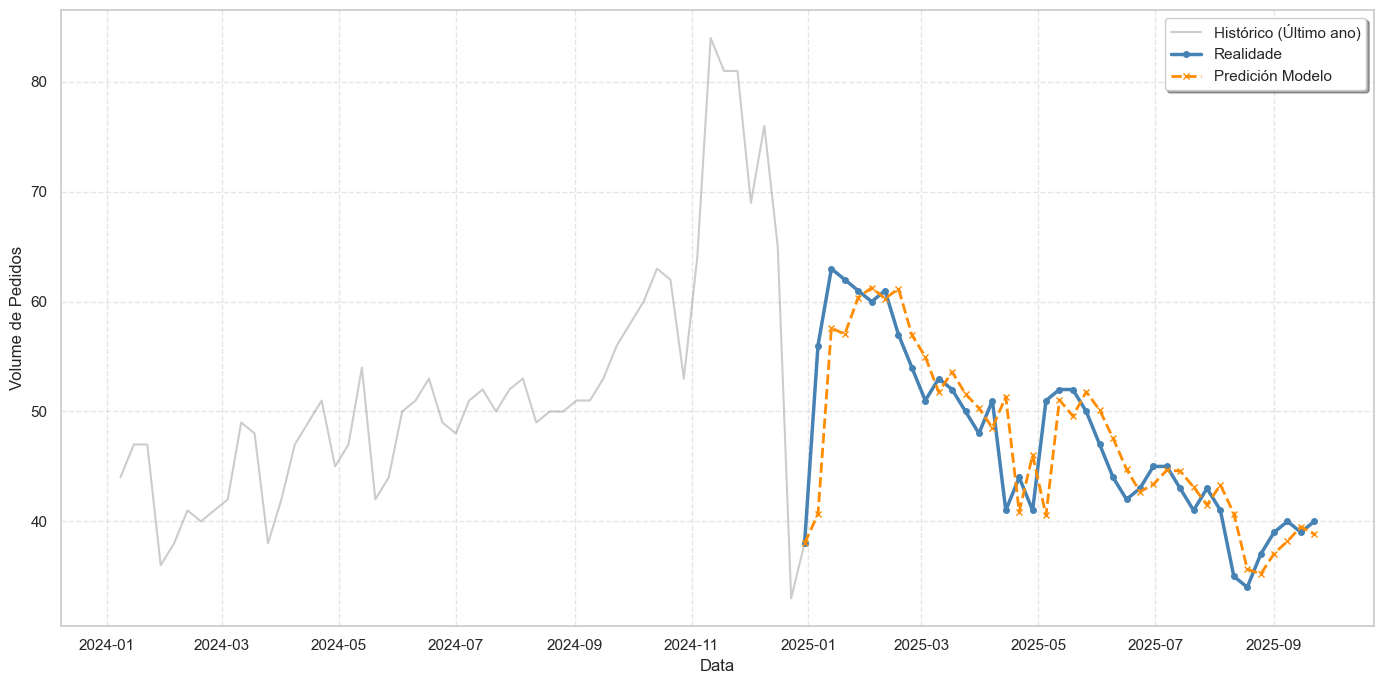

In [81]:
modelo = 'Cluster 2'
print(f"---  VALIDACIÓN ROLLING WINDOW: {modelo} ---")


datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")


preds_rolling_log = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], 
    order=datos_arima[modelo]['order'],
    trend='n',             
    verbose=True           
)

# Desfacemos a transformación log
preds_rolling = np.exp(preds_rolling_log)
datos_arima[modelo]['y_train'] = np.exp(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.exp(datos_arima[modelo]['y_test'])

# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling

# REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [82]:
modelo = 'Cluster 2'
#  CÁLCULO DE MÉTRICAS
# m=1 porque non hai estacionalidade no modelo 
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- AVALIACIÓN: Cluster 2 (Rolling) ---
MAE:  3.07
RMSE: 4.32
MAPE: 6.49%
MASE: 0.55 (Non Estacional (m=1))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Gardamos a información da análise de intervención e atípicos para empregar nos modelos Prophet:

In [83]:
modelo = 'Cluster 2'
# 1. Inicializamos o dicionario mestre (se non existe xa)
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"---  GARDADO FINAL PARA PROPHET: {modelo} ---")

# 3. Chamamos á función de empaquetado
df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

# 4. Gardamos no dicionario
export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

---  GARDADO FINAL PARA PROPHET: Cluster 2 ---
    Empaquetando datos de Cluster 2 para Prophet...

 Datos exportados para Cluster 2.
   Dimensións: (195, 5)
   Columnas incluídas: ['semana', 'n_pedidos', 'outlier_20220131', 'outlier_20241223', 'outlier_20231225']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  outlier_20220131  outlier_20241223  \
190 2025-08-25       37.0                 0                 0   
191 2025-09-01       39.0                 0                 0   
192 2025-09-08       40.0                 0                 0   
193 2025-09-15       39.0                 0                 0   
194 2025-09-22       40.0                 0                 0   

     outlier_20231225  
190                 0  
191                 0  
192                 0  
193                 0  
194                 0  


### Cluster 3

Recordemos que o terceiro cluster estaba formado polos clientes de alimentación e industria.

In [84]:
df_cluster_3 = datos['Cluster 3'].set_index('semana')

#### Análise de intervención: efecto do Black Friday

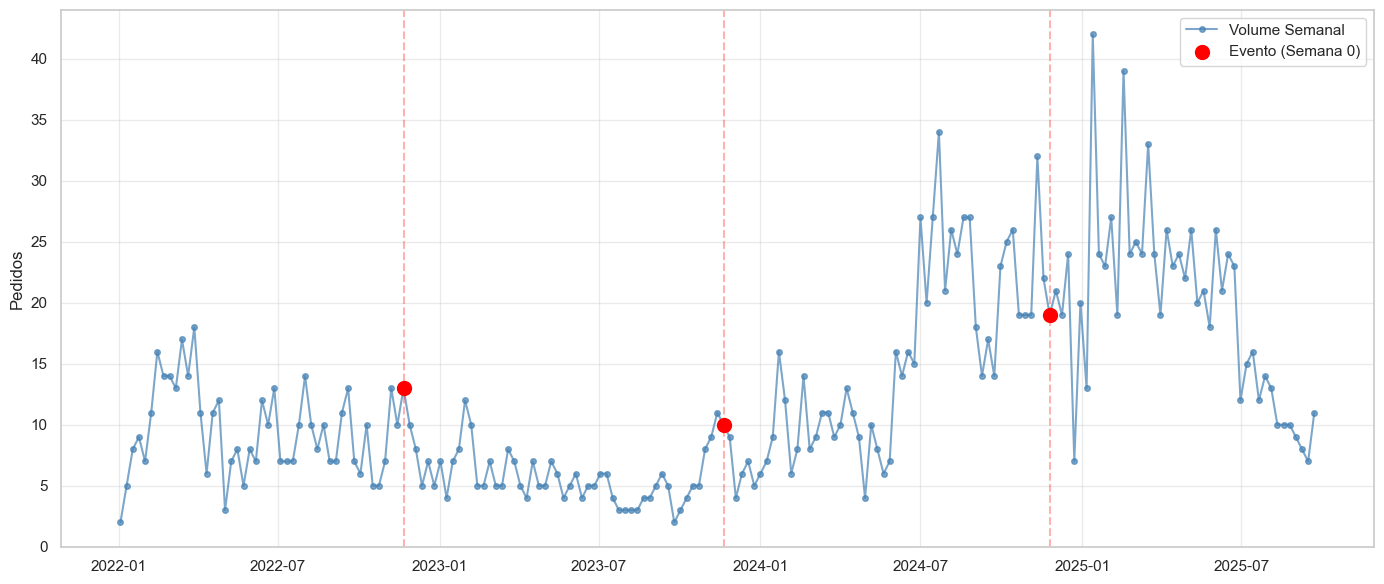

In [85]:
ft.plot_analisis_intervencion(df_input=df_cluster_3,
                              fechas_clave=fechas_bf)

Para os clientes deste cluster non apreciamos visualmente un gran impacto do Black Friday nin previo nin posterior. Porén, podemos modelar dita intervención e ver posterioremente se ten efecto significativo ou non á hora de axustar o modelo. 

In [86]:
modelo = 'Cluster 3'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_3)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=1, 
        weeks_post=1
    )

cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

##### Gráfico secuencial, fas e fap mostrais

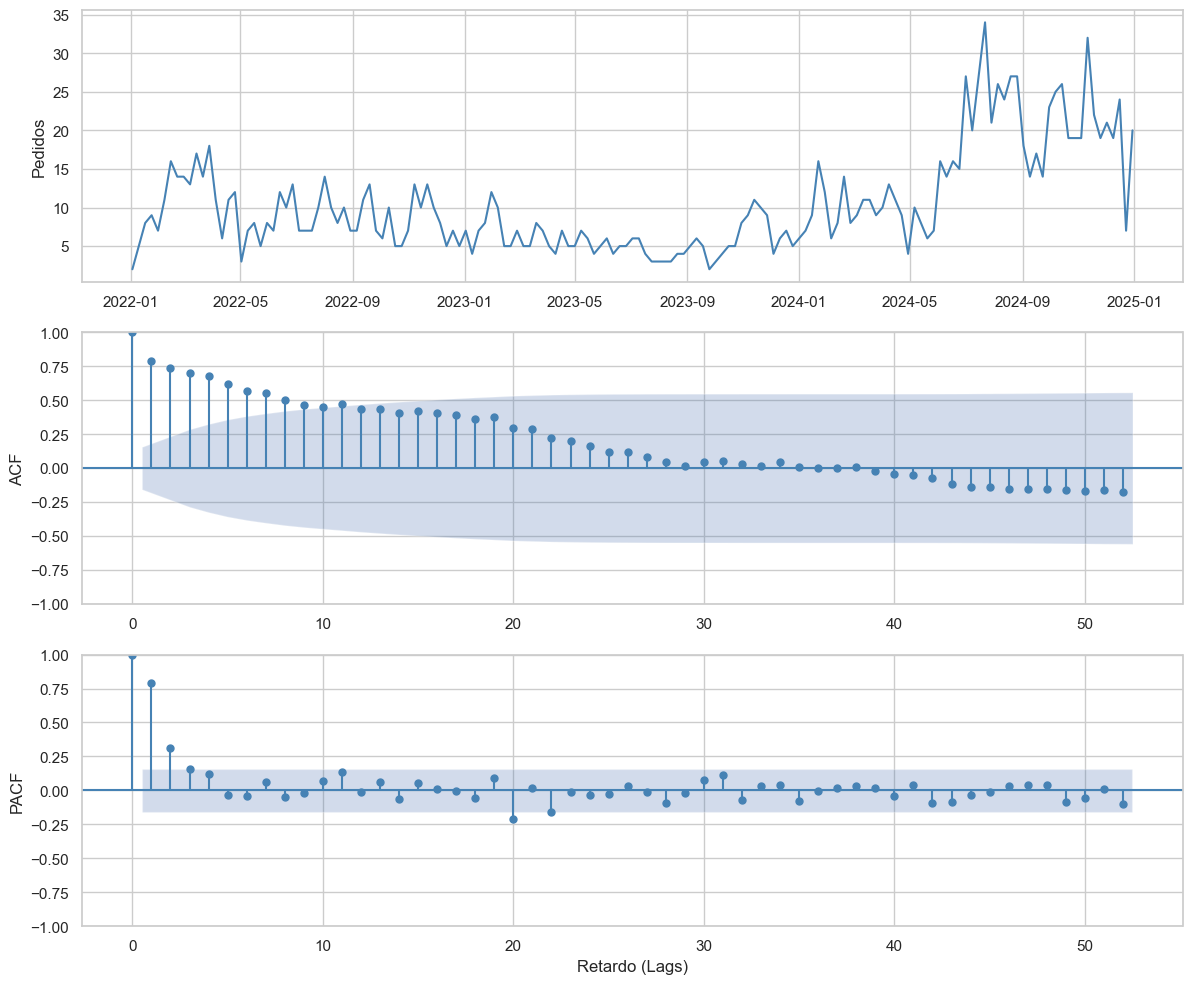

In [87]:
modelo = 'Cluster 3'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

No gráfico secuencial podemos observar un posible problema de heterocedasticidade, ata maio do 2024 a varianza é pequena, mentres que a partir deste momento, ademáis de crecer o nivel medio tamén oscila de forma máis significativa. Polo tanto procederemos a aplicar a transformación log á nosa serie.

In [88]:
modelo = 'Cluster 3'
datos_arima[modelo]['y_train'] = np.log(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.log(datos_arima[modelo]['y_test'])

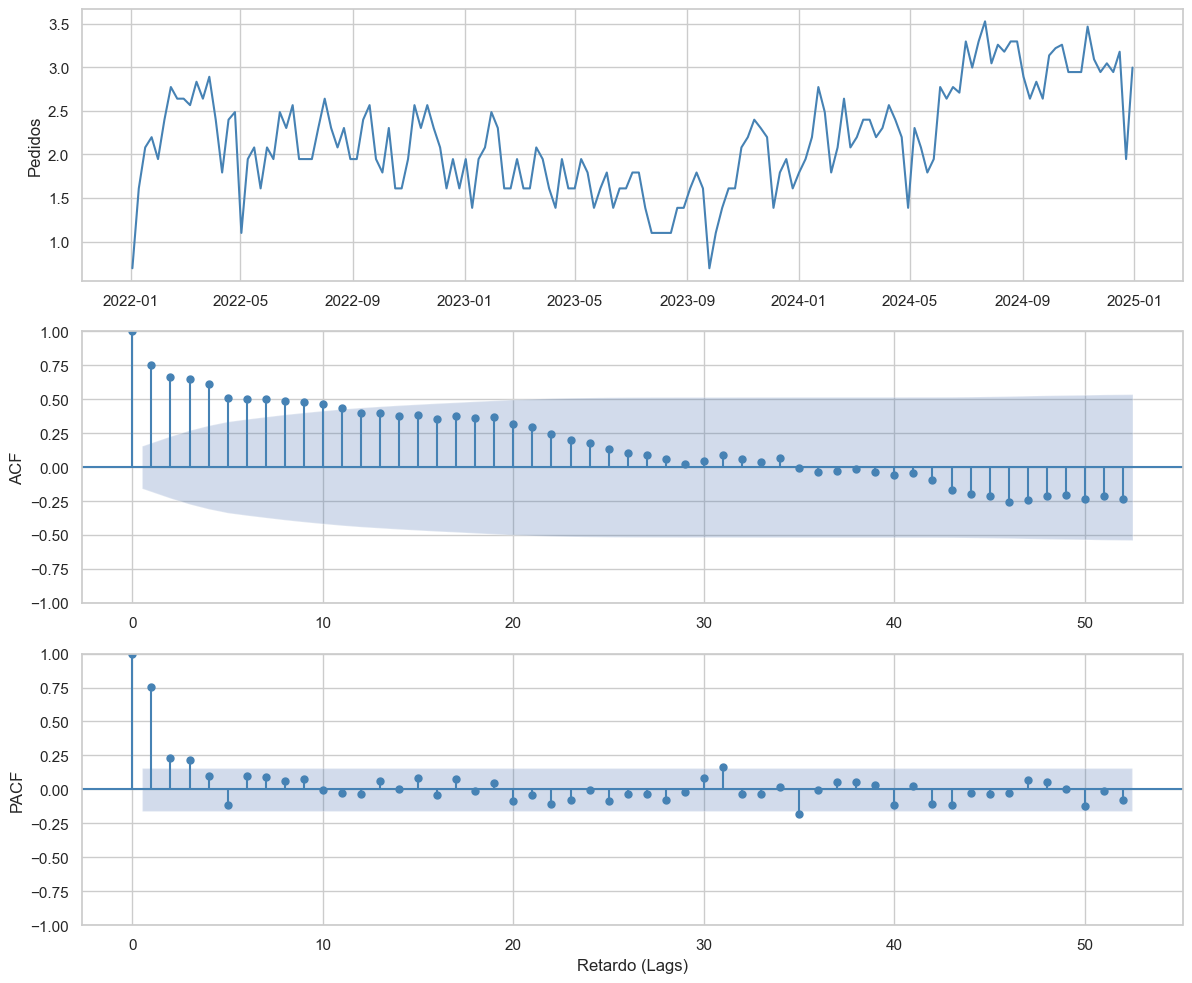

In [90]:
modelo = 'Cluster 3'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52
)

Estando o problema de heterocedasticidade corrixido, seguimos vendo tendencia a partir de maio de 2024 fundamentalmente. Daquela diferenciamos a serie.

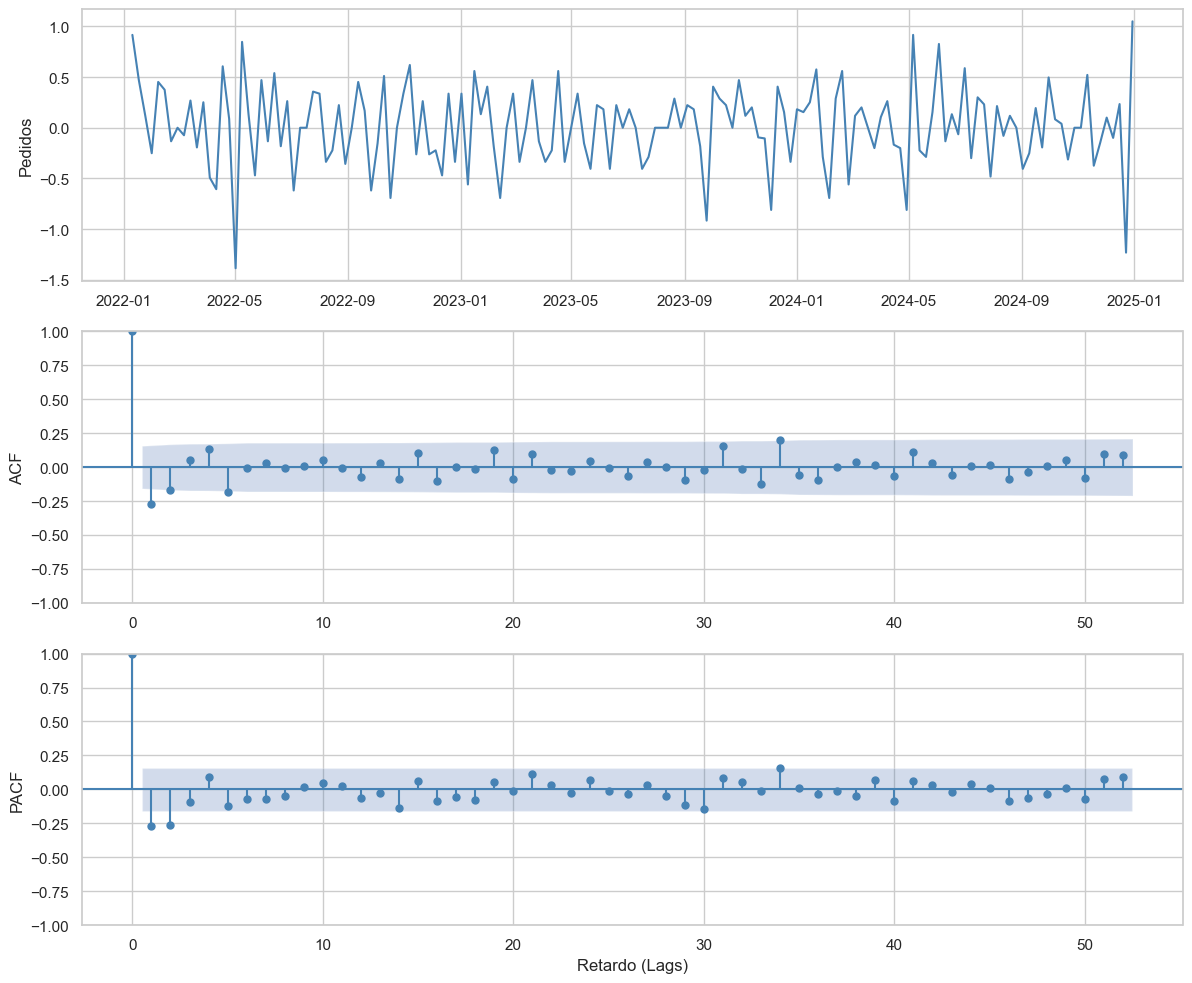

In [91]:
modelo = 'Cluster 3'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52
)

Unha vez diferenciada a serie transformada, os problemas de tendencia corríxense.  

Daquela, a serie diferenciada pode vir explicada ou ben por un MA(1) ou ben por un AR(2). Así, un modelo para a serie orixinal (transformada) podería ser ARIMA(0,1,1) ou ARIMA(2,1,0).

#### Selección do modelo mediante AICc

In [92]:
modelo = 'Cluster 3'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=163.323, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=152.370, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=139.997, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=161.540, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=138.727, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=139.095, Time=0.12 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=139.898, Time=0.17 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=137.963, Time=0.11 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=139.866, Time=0.13 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=140.890, Time=0.25 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=136.543, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=138.431, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=138.459, Time=0.07 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=138.410, Ti

In [93]:
modelo = 'Cluster 3'

manual_order = (2, 1, 0)


model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')


model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])


best_order = manual_order

print(f" Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

 Modelo ARIMA (2, 1, 0) axustado correctamente.
AIC = 137.7299724794667


In [94]:
best_order  = (0,1,2)

#### Detección de atípicos (aditivos e innovativos)

Pasamos agora a facer o contraste de outliers e engadir dita información ao noso modelo:

In [95]:
modelo = 'Cluster 3'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))


datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2022-05-02 | t-stat: 3.85 > 3.59
   [Iter 2] Non se atoparon máis atípicos significativos (Max t: 3.31). Fin.
       fecha    t_stat  iter      tipo
0 2022-05-02 -3.850211     1  Negativo
            bf_pre  bf_peak  bf_post  outlier_20220502
semana                                                
2022-01-03       0        0        0                 0
2022-01-10       0        0        0                 0
2022-01-17       0        0        0                 0
2022-01-24       0        0        0                 0
2022-01-31       0        0        0                 0


Un atípico en 02/05/2022.

#### Estimación ou axuste do modelo

In [96]:
modelo = 'Cluster 3'
print(f" Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")


model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       
    order = datos_arima[modelo]['order'],        
    trend ='n',                
    enforce_stationarity=False,
    enforce_invertibility=False
)

#  Adestramos
modelo_final = model_axuste.fit(disp=False)

# Mostramos a táboa de significación
print(modelo_final.summary())

 Axustando modelo final SARIMAX(0, 1, 2) con 4 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -48.055
Date:                Thu, 22 Jan 2026   AIC                            110.110
Time:                        18:35:16   BIC                            131.323
Sample:                    01-03-2022   HQIC                           118.727
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0.2065      0.210      0.984      0.325      -0.205       0.618
bf_peak              0.3512      0.268      

Vemos como os coeficientes correspondentes ao impacto do Black Friday non son significativos. Comezamos eliminando o menos significativo pre-BF:

In [ ]:
modelo = 'Cluster 3'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_post'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borrache).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        
    order=datos_arima[modelo]['order'],
    trend='n',                    
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_post'...
 Variable 'bf_post' eliminada correctamente das matrices.
 Reaxustando SARIMAX(0, 1, 2) coas 3 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -49.475
Date:                Thu, 22 Jan 2026   AIC                            110.950
Time:                        18:35:26   BIC                            129.132
Sample:                    01-03-2022   HQIC                           118.336
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               

Agora a menos significativa é a variable dummy que capta o efecto do propio BF. Quitámola do modelo:

In [98]:
modelo = 'Cluster 3'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borrache).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
 Variable 'bf_pre' eliminada correctamente das matrices.
 Reaxustando SARIMAX(0, 1, 2) coas 2 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -49.904
Date:                Thu, 22 Jan 2026   AIC                            109.808
Time:                        18:36:10   BIC                            124.960
Sample:                    01-03-2022   HQIC                           115.963
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_peak              0.

In [100]:
modelo = 'Cluster 3'
print(" Aplicando 'Backward Elimination': Eliminando 'bf_peak'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_peak'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f" Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f" A variable '{variable_a_borrar}' non se atopou (quizais xa a borrache).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f" Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

 Aplicando 'Backward Elimination': Eliminando 'bf_peak'...
 A variable 'bf_peak' non se atopou (quizais xa a borrache).
 Reaxustando SARIMAX(0, 1, 2) coas 1 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -50.346
Date:                Thu, 22 Jan 2026   AIC                            108.691
Time:                        18:36:26   BIC                            120.813
Sample:                    01-03-2022   HQIC                           113.615
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220502  

Todos os coeficientes significativos.

#### Diagnose ou análise dos residuos

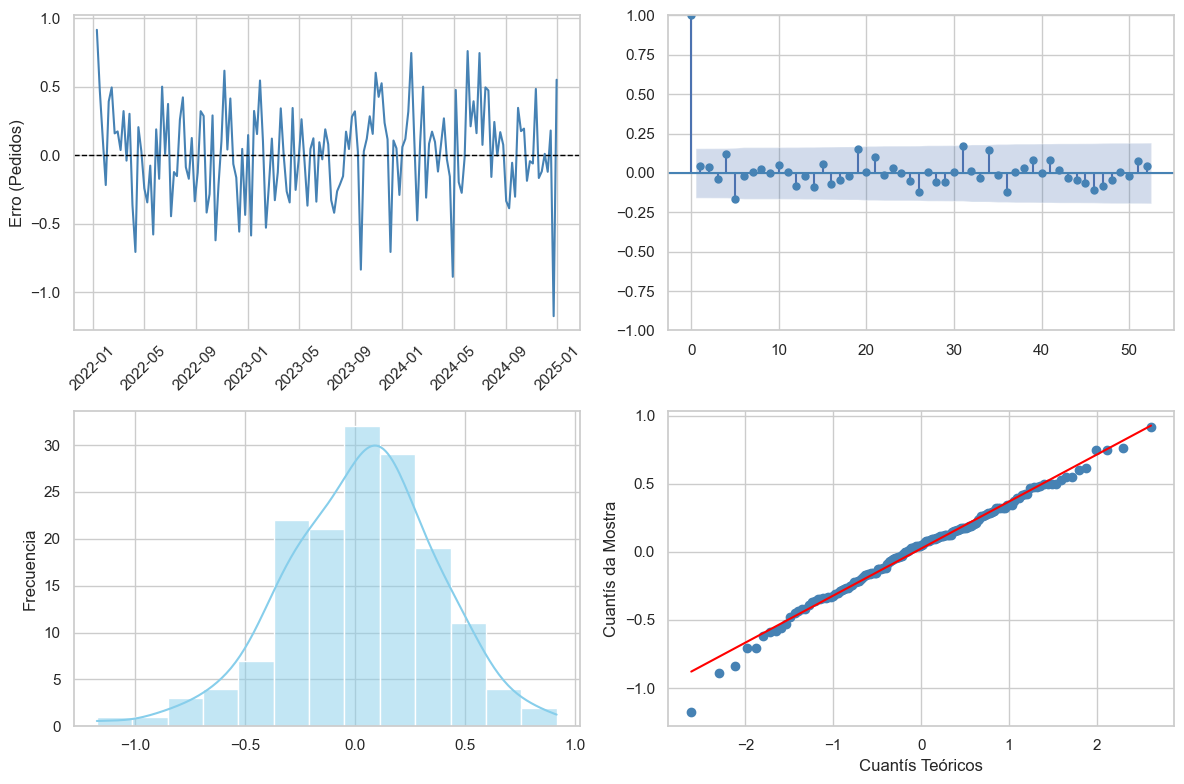


 --- INFORME ESTATÍSTICO ---
 Nesgo (Media=0):  p-value = 0.3908
  Normalidade (Shapiro): p-value = 0.3778
------------------------------------------------------------


In [101]:
ft.analizar_residuos_arima(modelo_final,lags=52)

Graficamente non observamos problemas de correlación ou heterocedasticidade. En relación á normalidade, os residuos presentan certa asimetría co cal é posible que non se vaia cumprir.

In [102]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -50.346
Date:                Thu, 22 Jan 2026   AIC                            108.691
Time:                        18:36:49   BIC                            120.813
Sample:                    01-03-2022   HQIC                           113.615
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220502    -1.0876      0.358     -3.037      0.002      -1.790      -0.386
ma.L1               -0.4569      0.088     -5.219      0.000      -0.628      -0.285
ma.L2               -0.2158      0.085     -2.539      0.011      -0.382      -0.049
sigma2               0.1129      0.012      9.607      0.000       0.090       0.136
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 6.19
Prob(Q):                              0.81   Prob(JB):                         0.05
Heteroskedasticity (H):               1.29   Skew:                            -0.42
Prob(H) (two-sided):                  0.37   Kurtosis:                         3.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Modelo válido con innovacións non gaussianas.

#### Predicións

Da mesma forma que no cluster 2, axustamos o modelo para os datos transformados (log), co cal á hora de predecir debemos facer a transformación inversa (exp):

---  VALIDACIÓN ROLLING WINDOW: Cluster 3 ---
   Variables en modelo: 1
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (0, 1, 2)
 Iniciando Rolling Window ARIMAX (38 semanas)...
   > Semana 10/38: Pred=3.23
   > Semana 20/38: Pred=3.09
   > Semana 30/38: Pred=2.68


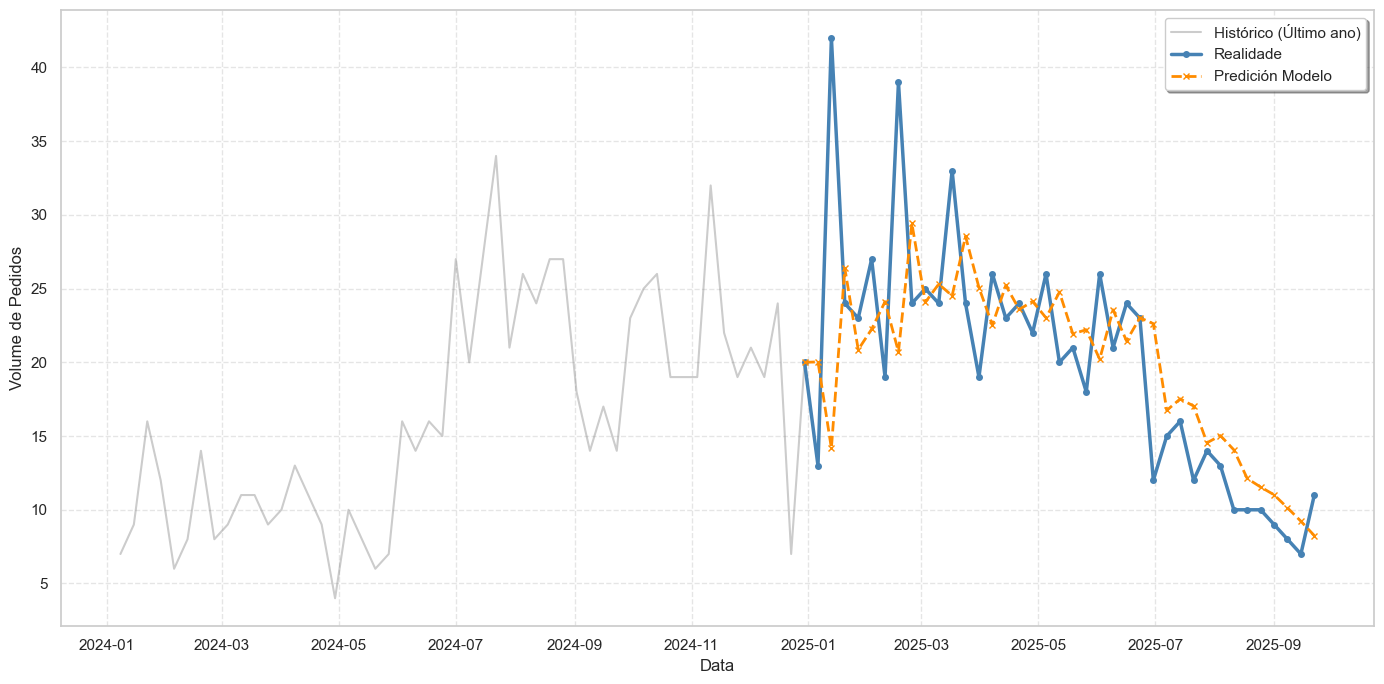

In [103]:
modelo = 'Cluster 3'
print(f"---  VALIDACIÓN ROLLING WINDOW: {modelo} ---")


datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")


preds_rolling_log = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], 
    order=datos_arima[modelo]['order'],
    trend='n',             
    verbose=True           
)

# Desfacemos a transformación log
preds_rolling = np.exp(preds_rolling_log)
datos_arima[modelo]['y_train'] = np.exp(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.exp(datos_arima[modelo]['y_test'])

# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling

# 6. REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=preds_rolling,
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [104]:
modelo = 'Cluster 3'
# 5. CÁLCULO DE MÉTRICAS
# m=1 porque non hai estacionalidade no modelo 
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)

--- AVALIACIÓN: Cluster 3 (Rolling) ---
MAE:  4.33
RMSE: 6.67
MAPE: 22.01%
MASE: 1.44 (Non Estacional (m=1))
 CONCLUSIÓN: O modelo non supera ao benchmark (MASE > 1).


Rendemento peor aos datos orixinais.

Neste último sector obtemos un rendemento bastante peor: MAPE = 20.78% e MASE = 1.38. Isto débese principalmente aos tres primeiros meses do 2025, onde se observan semanas con volume de envíos claramente superior ao habitual nos clientes deste sector. **Interesa ver se os datos destas semanas se deben a algún feito coñecido**

En particular, podemos calcular as métricas prescindindo do primeiro trimestre do ano (onde se ven comportamentos anómalos), para avaliar así o rendemento do modelo no período de comportamento máis estable do sector.

In [105]:
modelo = 'Cluster 3'

print(f"---  ANÁLISE DE SENSIBILIDADE (SEN Q1 2025) PARA: {modelo} ---")

# 1. Definimos a data de corte (Inicio do Q2)
start_date_Q2 = '2025-04-01'

# 2. Filtramos as series 
# y_test: A realidade completa
# preds_rolling: A predición completa 
y_true_clean = datos_arima[modelo]['y_test'].loc[start_date_Q2:]
y_pred_clean = datos_arima[modelo]['predicions'].loc[start_date_Q2:]

print(f"   Datos totais 2025: {len(datos_arima[modelo]['y_test'])} semanas")
print(f"   Datos analizados (Abr-Dec): {len(y_true_clean)} semanas")

if len(y_true_clean) > 0:
    metricas_clean = ft.calcular_metricas_completas(
        y_true=y_true_clean,
        y_pred=y_pred_clean,
        y_train=datos_arima[modelo]['y_train'], 
        m=1, 
        etiqueta=f"{modelo} (Sen Q1)"
    )
    
    
    print("\n   --- MELLORA OBTIDA AO ELIMINAR Q1 ---")
    
    for key in ['MAE', 'RMSE', 'MAPE', 'MASE']:
        valor_total = metricas[key]
        valor_clean = metricas_clean[key]
        diff = valor_total - valor_clean
        

        estado = " Mellora" if diff > 0 else " Empeora"
        print(f"   {key}: {valor_total:.2f} -> {valor_clean:.2f} | Dif: {diff:.2f} ({estado})")

else:
    print(" Erro: Non quedan datos despois do corte.")

datos_arima[modelo]['metricas'] = metricas_clean

---  ANÁLISE DE SENSIBILIDADE (SEN Q1 2025) PARA: Cluster 3 ---
   Datos totais 2025: 38 semanas
   Datos analizados (Abr-Dec): 25 semanas
--- AVALIACIÓN: Cluster 3 (Sen Q1) ---
MAE:  2.82
RMSE: 3.53
MAPE: 19.88%
MASE: 0.94 (Non Estacional (m=1))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).

   --- MELLORA OBTIDA AO ELIMINAR Q1 ---
   MAE: 4.33 -> 2.82 | Dif: 1.52 ( Mellora)
   RMSE: 6.67 -> 3.53 | Dif: 3.14 ( Mellora)
   MAPE: 22.01 -> 19.88 | Dif: 2.13 ( Mellora)
   MASE: 1.44 -> 0.94 | Dif: 0.51 ( Mellora)


Resultados peores.

Gardamos a información da análise de intervención e atípicos para o Prophet:

In [106]:
modelo = 'Cluster 3'
# 1. Inicializamos o dicionario mestre (se non existe xa)
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"---  GARDADO FINAL PARA PROPHET: {modelo} ---")

# 3. Chamamos á función de empaquetado
df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

# 4. Gardamos no dicionario
export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

---  GARDADO FINAL PARA PROPHET: Cluster 3 ---
    Empaquetando datos de Cluster 3 para Prophet...

 Datos exportados para Cluster 3.
   Dimensións: (195, 3)
   Columnas incluídas: ['semana', 'n_pedidos', 'outlier_20220502']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  outlier_20220502
190 2025-08-25       10.0                 0
191 2025-09-01        9.0                 0
192 2025-09-08        8.0                 0
193 2025-09-15        7.0                 0
194 2025-09-22       11.0                 0


## Modelos Prophet

Probaremos agora cunha aproximación diferente, axustando os modelos Prophet. Estos son uns modelos aditivos de series temporais con compoñentes interpretables:

$y(t) = g(t) + s(t) + h(t) + \epsilon_t$,

onde

$g(t)$ é a tendencia.

$s(t)$ é a estacionalidade.

$h(t)$ é o efecto dos festivos ou eventos especiais.

$\epsilon_t$ o erro.

In [107]:
# LISTA DOS FESTIVOS:
festivos = [
    '2022-04-14', '2022-04-15', '2022-04-18',
    '2022-05-26', '2023-04-06', '2023-04-07', '2023-04-10',
    '2023-05-18', '2024-03-28', '2024-03-29', '2024-04-01',
    '2024-05-20', '2025-04-17', '2025-04-18',
    '2025-04-21', '2025-05-29'
]
df_festivos_prophet = ft.preparar_festivos_prophet(festivos)
# Dicionario para gardar resultados:
resultados_prophet = {}

Modifiquemos os nosos datos de entrenamento e test para que sexan válidos para o modelo Prophet. Cómpre sinalar que dito modelo precisa que incorporemos os datos mediante un dataframe con dúas columnas $ds$ e $y$. A primeira debe ser datos de datas e a segunda a nosa variable de interese.

### Modelo xeral

In [108]:
modelo = 'Global'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario

print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Global
    Prophet Prep: Train=157, Test=38
    Regresores detectados (5): ['bf_pre', 'bf_peak', 'bf_post']...
   Variables exóxenas detectadas (5): ['bf_pre', 'bf_peak', 'bf_post', 'outlier_20241223', 'outlier_20231225']


In [109]:
print(f"\n--- 🔧 TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['additive']      
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"    Mellores parámetros: {resultados_prophet[modelo]['params']}")


--- 🔧 TUNING: Global ---
 Iniciando Grid Search con 64 combinacións...


18:39:42 - cmdstanpy - INFO - Chain [1] start processing
18:39:43 - cmdstanpy - INFO - Chain [1] done processing
18:39:44 - cmdstanpy - INFO - Chain [1] start processing
18:39:44 - cmdstanpy - INFO - Chain [1] start processing
18:39:44 - cmdstanpy - INFO - Chain [1] start processing
18:39:44 - cmdstanpy - INFO - Chain [1] start processing
18:39:44 - cmdstanpy - INFO - Chain [1] start processing
18:39:44 - cmdstanpy - INFO - Chain [1] done processing
18:39:44 - cmdstanpy - INFO - Chain [1] done processing
18:39:44 - cmdstanpy - INFO - Chain [1] start processing
18:39:44 - cmdstanpy - INFO - Chain [1] done processing
18:39:44 - cmdstanpy - INFO - Chain [1] done processing
18:39:44 - cmdstanpy - INFO - Chain [1] done processing
18:39:45 - cmdstanpy - INFO - Chain [1] done processing
18:39:45 - cmdstanpy - INFO - Chain [1] start processing
18:39:45 - cmdstanpy - INFO - Chain [1] done processing
18:39:46 - cmdstanpy - INFO - Chain [1] start processing
18:39:46 - cmdstanpy - INFO - Chain [1]

   > Combinación 5/64: RMSE=21.5316


18:39:57 - cmdstanpy - INFO - Chain [1] start processing
18:39:57 - cmdstanpy - INFO - Chain [1] start processing
18:39:57 - cmdstanpy - INFO - Chain [1] start processing
18:39:57 - cmdstanpy - INFO - Chain [1] start processing
18:39:57 - cmdstanpy - INFO - Chain [1] done processing
18:39:57 - cmdstanpy - INFO - Chain [1] done processing
18:39:57 - cmdstanpy - INFO - Chain [1] start processing
18:39:57 - cmdstanpy - INFO - Chain [1] done processing
18:39:57 - cmdstanpy - INFO - Chain [1] done processing
18:39:57 - cmdstanpy - INFO - Chain [1] start processing
18:39:57 - cmdstanpy - INFO - Chain [1] done processing
18:39:57 - cmdstanpy - INFO - Chain [1] done processing
18:39:57 - cmdstanpy - INFO - Chain [1] start processing
18:39:57 - cmdstanpy - INFO - Chain [1] done processing
18:39:59 - cmdstanpy - INFO - Chain [1] start processing
18:39:59 - cmdstanpy - INFO - Chain [1] done processing
18:39:59 - cmdstanpy - INFO - Chain [1] start processing
18:39:59 - cmdstanpy - INFO - Chain [1]

   > Combinación 10/64: RMSE=21.0570


...

18:42:00 - cmdstanpy - INFO - Chain [1] start processing
18:42:00 - cmdstanpy - INFO - Chain [1] done processing
18:42:01 - cmdstanpy - INFO - Chain [1] start processing
18:42:01 - cmdstanpy - INFO - Chain [1] done processing
18:42:01 - cmdstanpy - INFO - Chain [1] start processing
18:42:01 - cmdstanpy - INFO - Chain [1] start processing
18:42:01 - cmdstanpy - INFO - Chain [1] start processing
18:42:01 - cmdstanpy - INFO - Chain [1] done processing
18:42:01 - cmdstanpy - INFO - Chain [1] done processing
18:42:01 - cmdstanpy - INFO - Chain [1] start processing
18:42:01 - cmdstanpy - INFO - Chain [1] done processing
18:42:01 - cmdstanpy - INFO - Chain [1] done processing
18:42:01 - cmdstanpy - INFO - Chain [1] start processing
18:42:01 - cmdstanpy - INFO - Chain [1] done processing
18:42:03 - cmdstanpy - INFO - Chain [1] start processing
18:42:03 - cmdstanpy - INFO - Chain [1] start processing
18:42:03 - cmdstanpy - INFO - Chain [1] done processing
18:42:03 - cmdstanpy - INFO - Chain [1]

   > Combinación 60/64: RMSE=20.0874


18:42:17 - cmdstanpy - INFO - Chain [1] start processing
18:42:17 - cmdstanpy - INFO - Chain [1] start processing
18:42:17 - cmdstanpy - INFO - Chain [1] start processing
18:42:17 - cmdstanpy - INFO - Chain [1] start processing
18:42:17 - cmdstanpy - INFO - Chain [1] done processing
18:42:17 - cmdstanpy - INFO - Chain [1] done processing
18:42:17 - cmdstanpy - INFO - Chain [1] start processing
18:42:17 - cmdstanpy - INFO - Chain [1] start processing
18:42:17 - cmdstanpy - INFO - Chain [1] done processing
18:42:17 - cmdstanpy - INFO - Chain [1] done processing
18:42:17 - cmdstanpy - INFO - Chain [1] done processing
18:42:18 - cmdstanpy - INFO - Chain [1] done processing
18:42:18 - cmdstanpy - INFO - Chain [1] start processing
18:42:18 - cmdstanpy - INFO - Chain [1] done processing
18:42:20 - cmdstanpy - INFO - Chain [1] start processing
18:42:20 - cmdstanpy - INFO - Chain [1] start processing
18:42:20 - cmdstanpy - INFO - Chain [1] done processing
18:42:20 - cmdstanpy - INFO - Chain [1]


 Grid Search Completado.
   Mellor RMSE: 19.1540
   Parámetros: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 1.0, 'seasonality_mode': 'additive'}
    Mellores parámetros: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 1.0, 'seasonality_mode': 'additive'}


18:42:27 - cmdstanpy - INFO - Chain [1] done processing


In [110]:
print(f"\n---  ROLLING WINDOW: {modelo} ---")

resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'],  # Usamos os que gañaron no tuning
    verbose=True
)

18:42:54 - cmdstanpy - INFO - Chain [1] start processing
18:42:54 - cmdstanpy - INFO - Chain [1] done processing
18:42:54 - cmdstanpy - INFO - Chain [1] start processing
18:42:54 - cmdstanpy - INFO - Chain [1] done processing
18:42:54 - cmdstanpy - INFO - Chain [1] start processing
18:42:54 - cmdstanpy - INFO - Chain [1] done processing



---  ROLLING WINDOW: Global ---
 Iniciando Prophet Rolling Window (38 pasos)...


18:42:54 - cmdstanpy - INFO - Chain [1] start processing
18:42:54 - cmdstanpy - INFO - Chain [1] done processing
18:42:54 - cmdstanpy - INFO - Chain [1] start processing
18:42:54 - cmdstanpy - INFO - Chain [1] done processing
18:42:54 - cmdstanpy - INFO - Chain [1] start processing
18:42:54 - cmdstanpy - INFO - Chain [1] done processing
18:42:54 - cmdstanpy - INFO - Chain [1] start processing
18:42:54 - cmdstanpy - INFO - Chain [1] done processing
18:42:54 - cmdstanpy - INFO - Chain [1] start processing
18:42:54 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1]

   > Semana 10/38: Pred=110.14


18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1] done processing
18:42:55 - cmdstanpy - INFO - Chain [1] start processing
18:42:55 - cmdstanpy - INFO - Chain [1]

   > Semana 20/38: Pred=111.13


18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] 

   > Semana 30/38: Pred=88.92


18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:56 - cmdstanpy - INFO - Chain [1] done processing
18:42:56 - cmdstanpy - INFO - Chain [1] start processing
18:42:57 - cmdstanpy - INFO - Chain [1] done processing



---  ANÁLISE GRÁFICA: Global ---


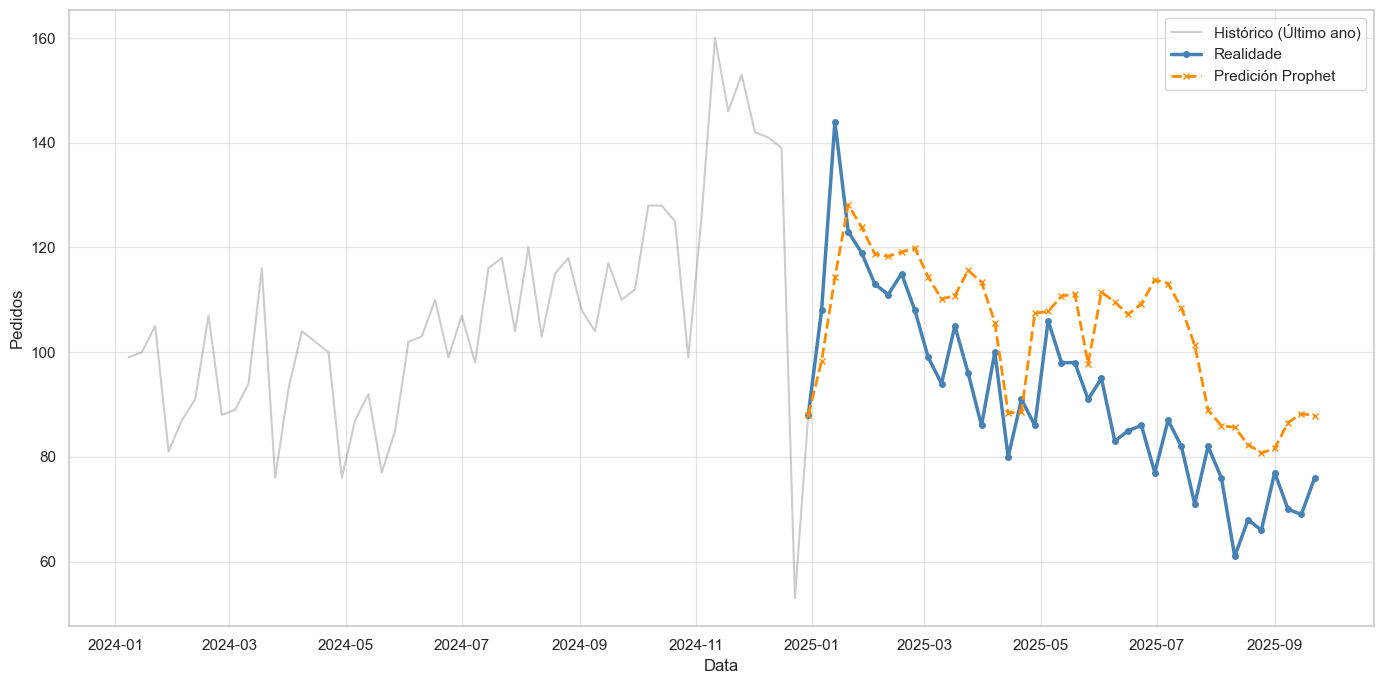

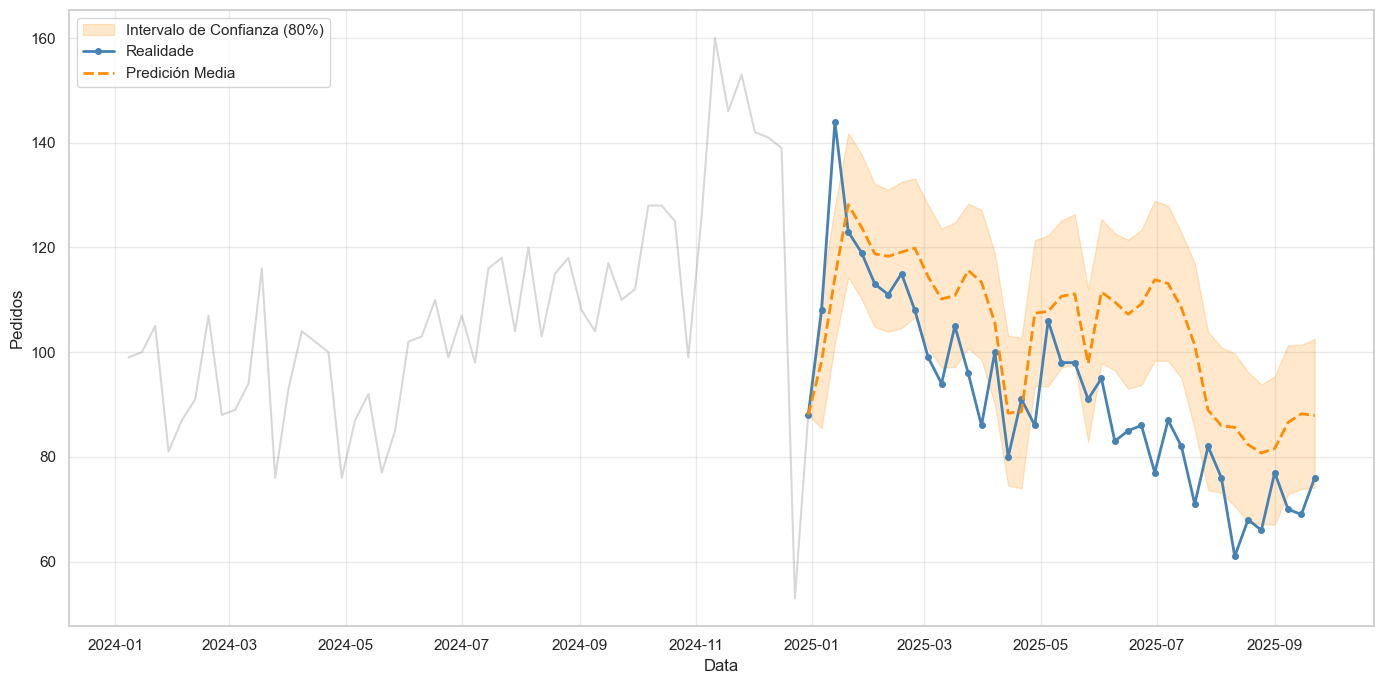

In [111]:
print(f"\n---  ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade (Estilo ARIMA)
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza (Exclusivo Prophet)
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

E avaliamos o rendemento do modelo:

Neste caso, como temos estacionalidade anual, debemos modificar a función que calcula o MASE posto que agora temos que comparar coa predición naïve do valor $x_t$ co valor observado $s=52$ instantes previos $x_{t-52}$, polo tanto debemos cambiar o denominador de dita medida do erro:

In [112]:
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- AVALIACIÓN: Prophet - Global ---
MAE:  14.90
RMSE: 17.43
MAPE: 17.57%
MASE: 0.71 (Estacional (m=52))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


18:43:28 - cmdstanpy - INFO - Chain [1] start processing
18:43:28 - cmdstanpy - INFO - Chain [1] done processing


  Xerando compoñentes...


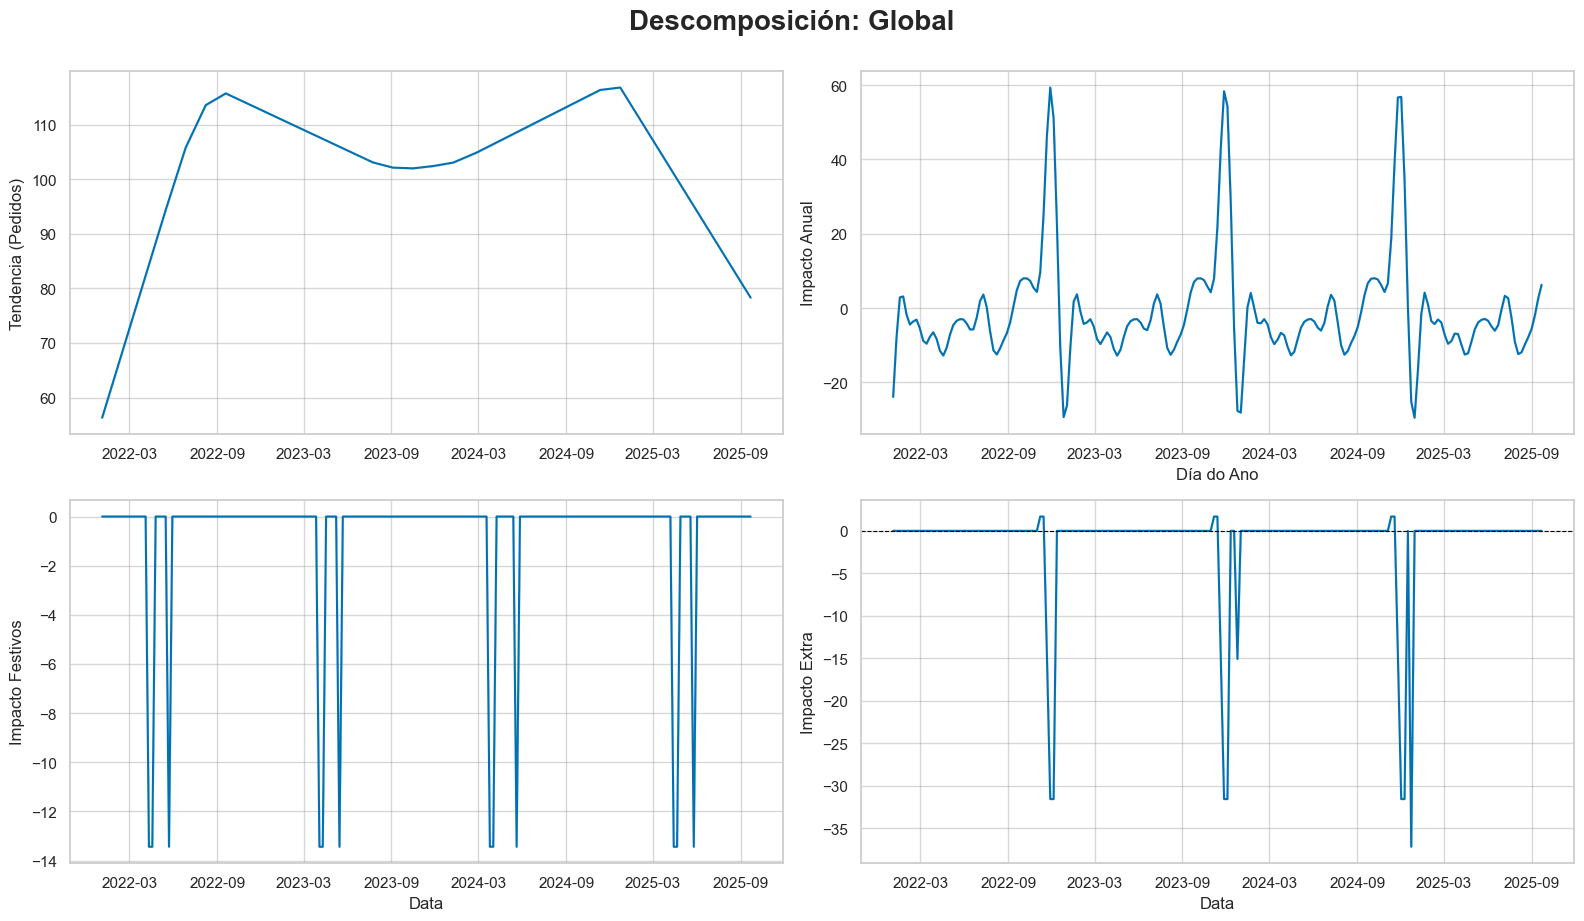

In [113]:
print("  Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), 
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

Da mesma forma que fixemos para os modelos ARIMA, podemos pensar agora en axustar un modelo para cada cluster de clientes e ver se desta forma construímos un modelo mellor.

### Cluster 1:

Debemos repetir o proceso anterior para os datos do cluster 1, que recordemos que representaba aos clientes de transporte, retail e electrónica.

In [114]:
modelo = 'Cluster 1'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario

print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 1
    Prophet Prep: Train=157, Test=38
    Regresores detectados (3): ['bf_peak', 'bf_post', 'outlier_20231225']...
   Variables exóxenas detectadas (3): ['bf_peak', 'bf_post', 'outlier_20231225']


In [115]:
print(f"\n--- TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['additive']      
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"   Mellores parámetros: {resultados_prophet[modelo]['params']}")

18:43:50 - cmdstanpy - INFO - Chain [1] start processing
18:43:50 - cmdstanpy - INFO - Chain [1] done processing



--- TUNING: Cluster 1 ---
 Iniciando Grid Search con 64 combinacións...


18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:55 - cmdstanpy - INFO - Chain [1] start processing
18:43:55 - cmdstanpy - INFO - Chain [1] done processing
18:43:55 - cmdstanpy - INFO - Chain [1] start processing
18:43:55 - cmdstanpy - INFO - Chain [1]

   > Combinación 5/64: RMSE=19.6001


18:44:03 - cmdstanpy - INFO - Chain [1] start processing
18:44:03 - cmdstanpy - INFO - Chain [1] start processing
18:44:03 - cmdstanpy - INFO - Chain [1] done processing
18:44:03 - cmdstanpy - INFO - Chain [1] start processing
18:44:03 - cmdstanpy - INFO - Chain [1] start processing
18:44:03 - cmdstanpy - INFO - Chain [1] done processing
18:44:03 - cmdstanpy - INFO - Chain [1] done processing
18:44:03 - cmdstanpy - INFO - Chain [1] start processing
18:44:03 - cmdstanpy - INFO - Chain [1] done processing
18:44:03 - cmdstanpy - INFO - Chain [1] start processing
18:44:03 - cmdstanpy - INFO - Chain [1] done processing
18:44:03 - cmdstanpy - INFO - Chain [1] done processing
18:44:03 - cmdstanpy - INFO - Chain [1] start processing
18:44:03 - cmdstanpy - INFO - Chain [1] done processing
18:44:05 - cmdstanpy - INFO - Chain [1] start processing
18:44:05 - cmdstanpy - INFO - Chain [1] start processing
18:44:05 - cmdstanpy - INFO - Chain [1] done processing
18:44:05 - cmdstanpy - INFO - Chain [1]

...

18:45:58 - cmdstanpy - INFO - Chain [1] start processing
18:45:58 - cmdstanpy - INFO - Chain [1] done processing
18:45:58 - cmdstanpy - INFO - Chain [1] start processing
18:45:58 - cmdstanpy - INFO - Chain [1] start processing
18:45:58 - cmdstanpy - INFO - Chain [1] start processing
18:45:58 - cmdstanpy - INFO - Chain [1] start processing
18:45:58 - cmdstanpy - INFO - Chain [1] start processing
18:45:58 - cmdstanpy - INFO - Chain [1] done processing
18:45:58 - cmdstanpy - INFO - Chain [1] done processing
18:45:58 - cmdstanpy - INFO - Chain [1] done processing
18:45:58 - cmdstanpy - INFO - Chain [1] done processing
18:45:59 - cmdstanpy - INFO - Chain [1] done processing
18:45:59 - cmdstanpy - INFO - Chain [1] start processing
18:45:59 - cmdstanpy - INFO - Chain [1] done processing
18:46:01 - cmdstanpy - INFO - Chain [1] start processing
18:46:01 - cmdstanpy - INFO - Chain [1] start processing
18:46:01 - cmdstanpy - INFO - Chain [1] start processing
18:46:01 - cmdstanpy - INFO - Chain [1

   > Combinación 60/64: RMSE=14.8700


18:46:13 - cmdstanpy - INFO - Chain [1] start processing
18:46:13 - cmdstanpy - INFO - Chain [1] start processing
18:46:13 - cmdstanpy - INFO - Chain [1] start processing
18:46:13 - cmdstanpy - INFO - Chain [1] start processing
18:46:13 - cmdstanpy - INFO - Chain [1] done processing
18:46:13 - cmdstanpy - INFO - Chain [1] start processing
18:46:13 - cmdstanpy - INFO - Chain [1] done processing
18:46:13 - cmdstanpy - INFO - Chain [1] done processing
18:46:13 - cmdstanpy - INFO - Chain [1] start processing
18:46:13 - cmdstanpy - INFO - Chain [1] done processing
18:46:13 - cmdstanpy - INFO - Chain [1] done processing
18:46:14 - cmdstanpy - INFO - Chain [1] done processing
18:46:14 - cmdstanpy - INFO - Chain [1] start processing
18:46:14 - cmdstanpy - INFO - Chain [1] done processing
18:46:16 - cmdstanpy - INFO - Chain [1] start processing
18:46:16 - cmdstanpy - INFO - Chain [1] start processing
18:46:16 - cmdstanpy - INFO - Chain [1] done processing
18:46:16 - cmdstanpy - INFO - Chain [1]


 Grid Search Completado.
   Mellor RMSE: 13.6500
   Parámetros: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'additive'}
   Mellores parámetros: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'additive'}


18:46:24 - cmdstanpy - INFO - Chain [1] done processing


In [116]:
print(f"\n--- ROLLING WINDOW: {modelo} ---")

# 1. Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'],
    verbose=True
)

18:47:04 - cmdstanpy - INFO - Chain [1] start processing
18:47:04 - cmdstanpy - INFO - Chain [1] done processing
18:47:04 - cmdstanpy - INFO - Chain [1] start processing
18:47:04 - cmdstanpy - INFO - Chain [1] done processing
18:47:04 - cmdstanpy - INFO - Chain [1] start processing
18:47:04 - cmdstanpy - INFO - Chain [1] done processing



--- ROLLING WINDOW: Cluster 1 ---
 Iniciando Prophet Rolling Window (38 pasos)...


18:47:04 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1]

   > Semana 10/38: Pred=29.30


18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:05 - cmdstanpy - INFO - Chain [1] done processing
18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] 

   > Semana 20/38: Pred=26.85


18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] 

   > Semana 30/38: Pred=18.29


18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:07 - cmdstanpy - INFO - Chain [1] start processing
18:47:07 - cmdstanpy - INFO - Chain [1] done processing
18:47:07 - cmdstanpy - INFO - Chain [1] start processing
18:47:07 - cmdstanpy - INFO - Chain [1] done processing
18:47:07 - cmdstanpy - INFO - Chain [1] start processing
18:47:07 - cmdstanpy - INFO - Chain [1] done processing
18:47:07 - cmdstanpy - INFO - Chain [1] start processing
18:47:07 - cmdstanpy - INFO - Chain [1] done processing



---  ANÁLISE GRÁFICA: Cluster 1 ---


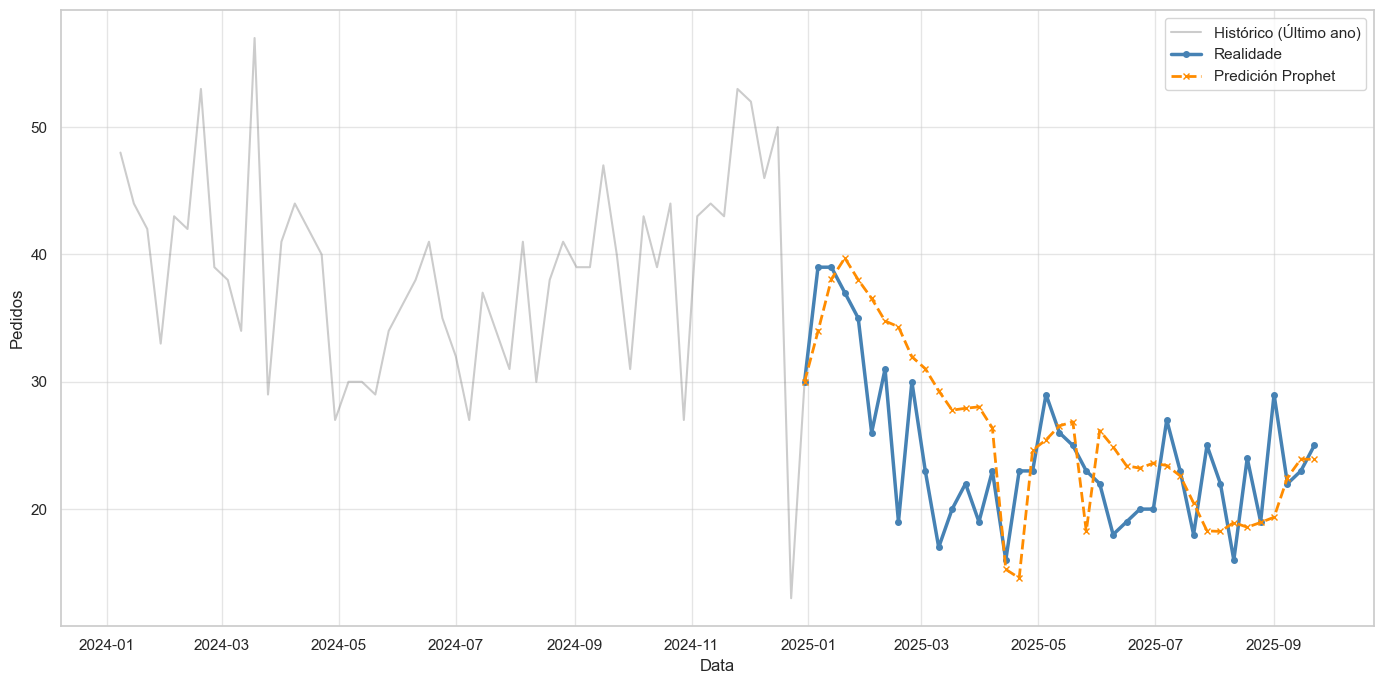

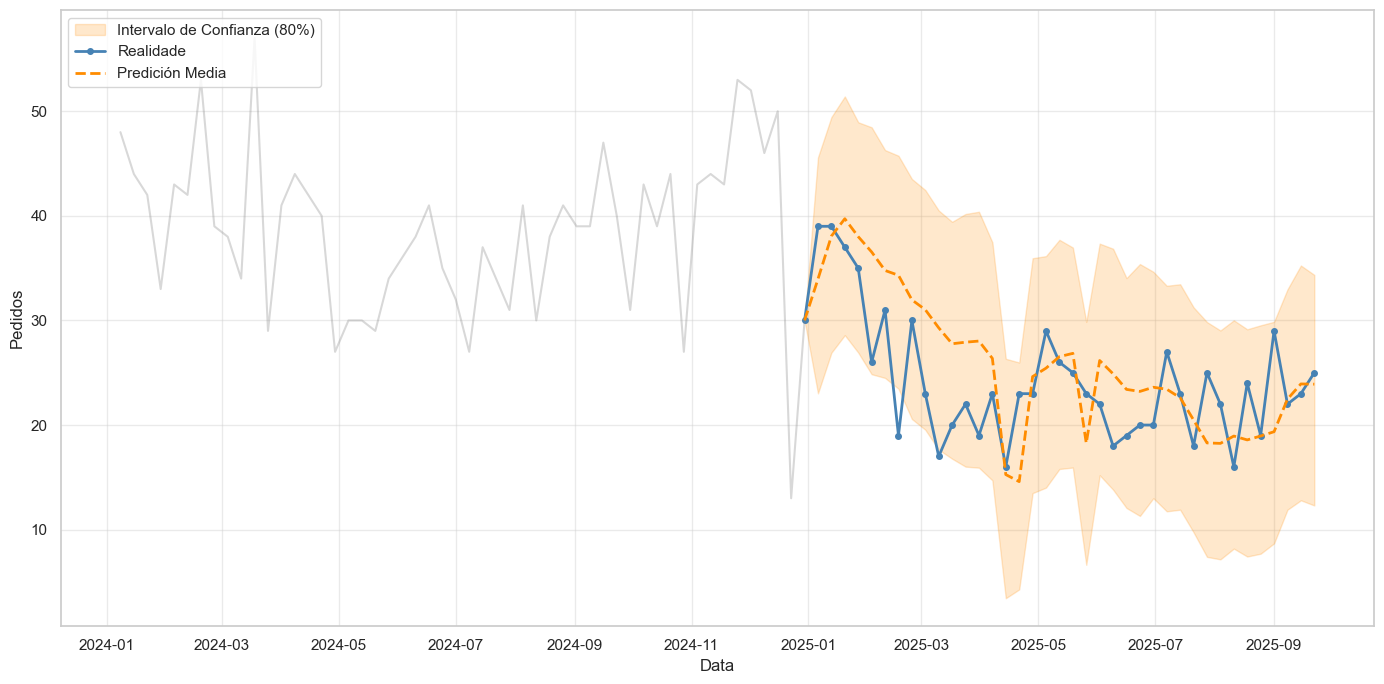

In [117]:
print(f"\n---  ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade 
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza 
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [118]:
# 2. Cálculo de Métricas 

resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- AVALIACIÓN: Prophet - Cluster 1 ---
MAE:  4.50
RMSE: 5.72
MAPE: 20.24%
MASE: 0.30 (Estacional (m=52))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


23:33:17 - cmdstanpy - INFO - Chain [1] start processing
23:33:17 - cmdstanpy - INFO - Chain [1] done processing


   🎨 Xerando compoñentes...


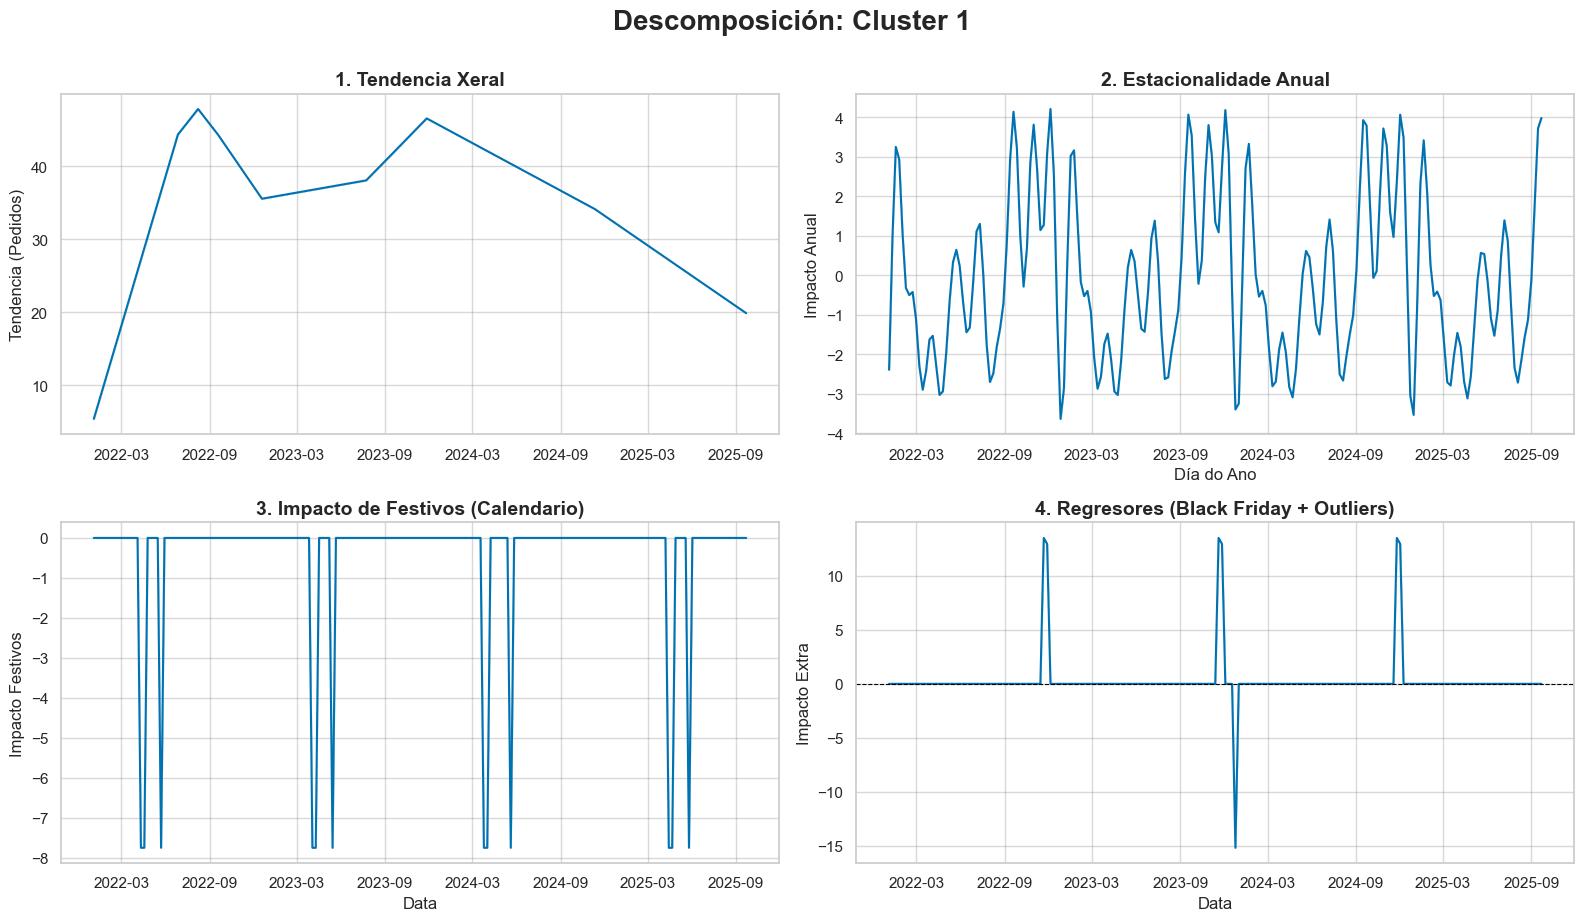

In [ ]:
# Compoñentes 
print("   Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), # Adestramos con todo para ver a foto completa
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

### Cluster 2

Facemos o propio para os clientes do cluster 2, que estaba formado polos clientes de paquetería e froita:

In [119]:
modelo = 'Cluster 2'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' 
)
# Gardamos no dicionario
print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 2
    Prophet Prep: Train=157, Test=38
    Regresores detectados (3): ['outlier_20220131', 'outlier_20241223', 'outlier_20231225']...
   Variables exóxenas detectadas (3): ['outlier_20220131', 'outlier_20241223', 'outlier_20231225']


In [120]:
print(f"\n--- 🔧 TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['multiplicative']      
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario
print(f"    Mellores parámetros: {resultados_prophet[modelo]['params']}")

18:48:52 - cmdstanpy - INFO - Chain [1] start processing
18:48:52 - cmdstanpy - INFO - Chain [1] done processing



--- 🔧 TUNING: Cluster 2 ---
 Iniciando Grid Search con 64 combinacións...


18:48:54 - cmdstanpy - INFO - Chain [1] start processing
18:48:54 - cmdstanpy - INFO - Chain [1] start processing
18:48:54 - cmdstanpy - INFO - Chain [1] start processing
18:48:54 - cmdstanpy - INFO - Chain [1] start processing
18:48:54 - cmdstanpy - INFO - Chain [1] start processing
18:48:54 - cmdstanpy - INFO - Chain [1] start processing
18:48:54 - cmdstanpy - INFO - Chain [1] done processing
18:48:54 - cmdstanpy - INFO - Chain [1] done processing
18:48:54 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
18:48:54 - cmdstanpy - INFO - Chain [1] done processing
18:48:54 - cmdstanpy - INFO - Chain [1] done processing
18:48:54 - cmdstanpy - INFO - Chain [1] start processing
18:48:54 - cmdstanpy - INFO - Chain [1] done processing
18:48:54 - cmdstanpy - INFO - Chain [1] done processing
18:48:54 - cmdstanpy - INFO - Chain [1] done processing
18:48:54 - cmdstanpy - INFO - Chain [1] start processing
18:48:54 - 

   > Combinación 5/64: RMSE=13.9349


18:49:05 - cmdstanpy - INFO - Chain [1] start processing
18:49:05 - cmdstanpy - INFO - Chain [1] start processing
18:49:05 - cmdstanpy - INFO - Chain [1] start processing
18:49:05 - cmdstanpy - INFO - Chain [1] start processing
18:49:05 - cmdstanpy - INFO - Chain [1] done processing
18:49:05 - cmdstanpy - INFO - Chain [1] done processing
18:49:05 - cmdstanpy - INFO - Chain [1] start processing
18:49:05 - cmdstanpy - INFO - Chain [1] done processing
18:49:05 - cmdstanpy - INFO - Chain [1] done processing
18:49:05 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
18:49:05 - cmdstanpy - INFO - Chain [1] start processing
18:49:05 - cmdstanpy - INFO - Chain [1] start processing
18:49:05 - cmdstanpy - INFO - Chain [1] done processing
18:49:05 - cmdstanpy - INFO - Chain [1] done processing
18:49:05 - cmdstanpy - INFO - Chain [1] done processing
18:49:05 - cmdstanpy - INFO - Chain [1] start processing
18:49:05 - 

...

18:51:48 - cmdstanpy - INFO - Chain [1] done processing
18:51:50 - cmdstanpy - INFO - Chain [1] start processing
18:51:50 - cmdstanpy - INFO - Chain [1] start processing
18:51:50 - cmdstanpy - INFO - Chain [1] start processing
18:51:50 - cmdstanpy - INFO - Chain [1] start processing
18:51:50 - cmdstanpy - INFO - Chain [1] start processing
18:51:50 - cmdstanpy - INFO - Chain [1] start processing
18:51:50 - cmdstanpy - INFO - Chain [1] done processing
18:51:51 - cmdstanpy - INFO - Chain [1] done processing
18:51:51 - cmdstanpy - INFO - Chain [1] done processing
18:51:51 - cmdstanpy - INFO - Chain [1] done processing
18:51:51 - cmdstanpy - INFO - Chain [1] done processing
18:51:51 - cmdstanpy - INFO - Chain [1] done processing
18:51:51 - cmdstanpy - INFO - Chain [1] start processing
18:51:51 - cmdstanpy - INFO - Chain [1] done processing
18:51:53 - cmdstanpy - INFO - Chain [1] start processing
18:51:53 - cmdstanpy - INFO - Chain [1] start processing
18:51:53 - cmdstanpy - INFO - Chain [1]

   > Combinación 60/64: RMSE=11.3150


18:52:09 - cmdstanpy - INFO - Chain [1] done processing
18:52:11 - cmdstanpy - INFO - Chain [1] start processing
18:52:11 - cmdstanpy - INFO - Chain [1] start processing
18:52:11 - cmdstanpy - INFO - Chain [1] start processing
18:52:11 - cmdstanpy - INFO - Chain [1] start processing
18:52:11 - cmdstanpy - INFO - Chain [1] start processing
18:52:11 - cmdstanpy - INFO - Chain [1] start processing
18:52:11 - cmdstanpy - INFO - Chain [1] done processing
18:52:11 - cmdstanpy - INFO - Chain [1] done processing
18:52:11 - cmdstanpy - INFO - Chain [1] done processing
18:52:11 - cmdstanpy - INFO - Chain [1] done processing
18:52:11 - cmdstanpy - INFO - Chain [1] done processing
18:52:12 - cmdstanpy - INFO - Chain [1] done processing
18:52:12 - cmdstanpy - INFO - Chain [1] start processing
18:52:13 - cmdstanpy - INFO - Chain [1] done processing
18:52:15 - cmdstanpy - INFO - Chain [1] start processing
18:52:15 - cmdstanpy - INFO - Chain [1] start processing
18:52:15 - cmdstanpy - INFO - Chain [1]


 Grid Search Completado.
   Mellor RMSE: 8.1317
   Parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 0.01, 'seasonality_mode': 'multiplicative'}
    Mellores parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 0.01, 'seasonality_mode': 'multiplicative'}


18:52:25 - cmdstanpy - INFO - Chain [1] done processing


In [121]:
print(f"\n---  ROLLING WINDOW: {modelo} ---")

resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'], 
    verbose=True
)

18:53:23 - cmdstanpy - INFO - Chain [1] start processing
18:53:23 - cmdstanpy - INFO - Chain [1] done processing
18:53:23 - cmdstanpy - INFO - Chain [1] start processing
18:53:23 - cmdstanpy - INFO - Chain [1] done processing
18:53:23 - cmdstanpy - INFO - Chain [1] start processing
18:53:23 - cmdstanpy - INFO - Chain [1] done processing
18:53:23 - cmdstanpy - INFO - Chain [1] start processing



---  ROLLING WINDOW: Cluster 2 ---
 Iniciando Prophet Rolling Window (38 pasos)...


18:53:23 - cmdstanpy - INFO - Chain [1] done processing
18:53:23 - cmdstanpy - INFO - Chain [1] start processing
18:53:23 - cmdstanpy - INFO - Chain [1] done processing
18:53:23 - cmdstanpy - INFO - Chain [1] start processing
18:53:23 - cmdstanpy - INFO - Chain [1] done processing
18:53:23 - cmdstanpy - INFO - Chain [1] start processing
18:53:23 - cmdstanpy - INFO - Chain [1] done processing
18:53:23 - cmdstanpy - INFO - Chain [1] start processing
18:53:23 - cmdstanpy - INFO - Chain [1] done processing
18:53:23 - cmdstanpy - INFO - Chain [1] start processing
18:53:23 - cmdstanpy - INFO - Chain [1] done processing
18:53:23 - cmdstanpy - INFO - Chain [1] start processing
18:53:23 - cmdstanpy - INFO - Chain [1] done processing
18:53:23 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] 

   > Semana 10/38: Pred=54.78


18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1]

   > Semana 20/38: Pred=54.07


18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:24 - cmdstanpy - INFO - Chain [1] done processing
18:53:24 - cmdstanpy - INFO - Chain [1] start processing
18:53:25 - cmdstanpy - INFO - Chain [1] done processing
18:53:25 - cmdstanpy - INFO - Chain [1] start processing
18:53:25 - cmdstanpy - INFO - Chain [1] done processing
18:53:25 - cmdstanpy - INFO - Chain [1] start processing
18:53:25 - cmdstanpy - INFO - Chain [1] done processing
18:53:25 - cmdstanpy - INFO - Chain [1] start processing
18:53:25 - cmdstanpy - INFO - Chain [1] done processing
18:53:25 - cmdstanpy - INFO - Chain [1] start processing
18:53:25 - cmdstanpy - INFO - Chain [1] done processing
18:53:25 - cmdstanpy - INFO - Chain [1] start processing
18:53:25 - cmdstanpy - INFO - Chain [1]

   > Semana 30/38: Pred=48.98


18:53:25 - cmdstanpy - INFO - Chain [1] start processing
18:53:25 - cmdstanpy - INFO - Chain [1] done processing
18:53:25 - cmdstanpy - INFO - Chain [1] start processing
18:53:25 - cmdstanpy - INFO - Chain [1] done processing
18:53:25 - cmdstanpy - INFO - Chain [1] start processing
18:53:25 - cmdstanpy - INFO - Chain [1] done processing
18:53:25 - cmdstanpy - INFO - Chain [1] start processing
18:53:25 - cmdstanpy - INFO - Chain [1] done processing



---  ANÁLISE GRÁFICA: Cluster 2 ---


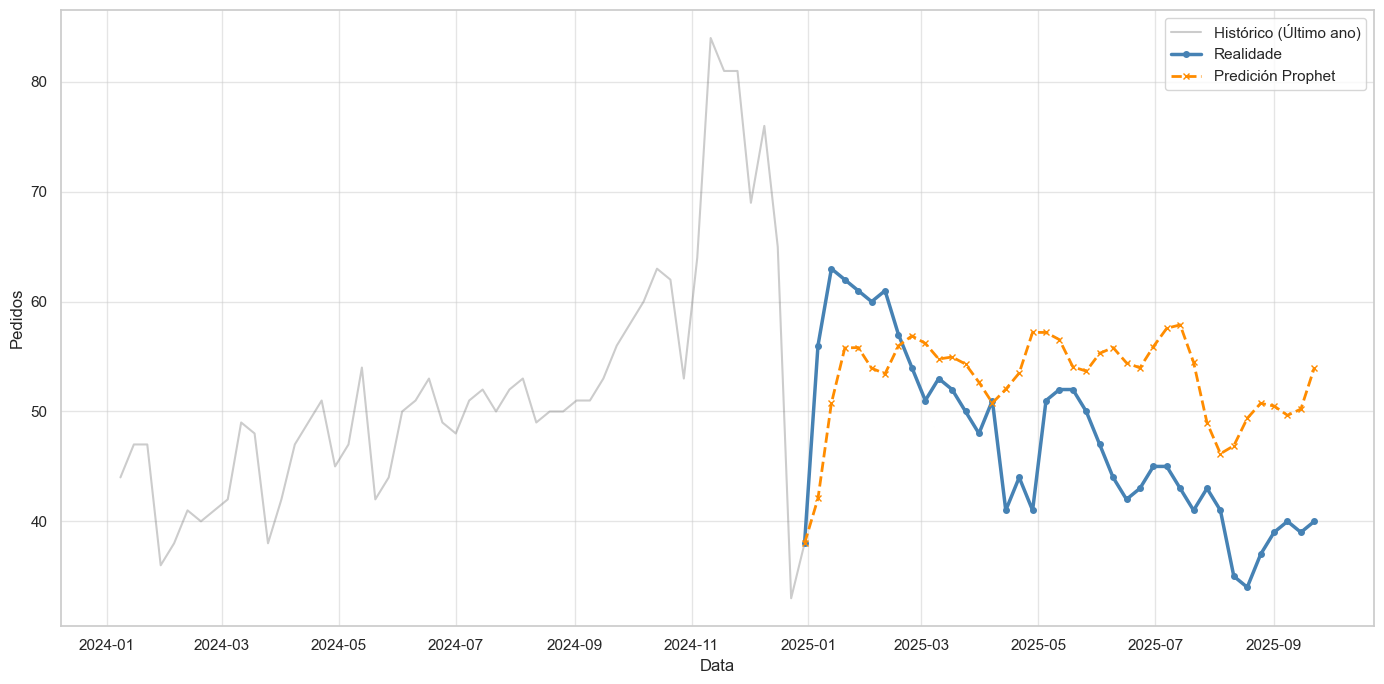

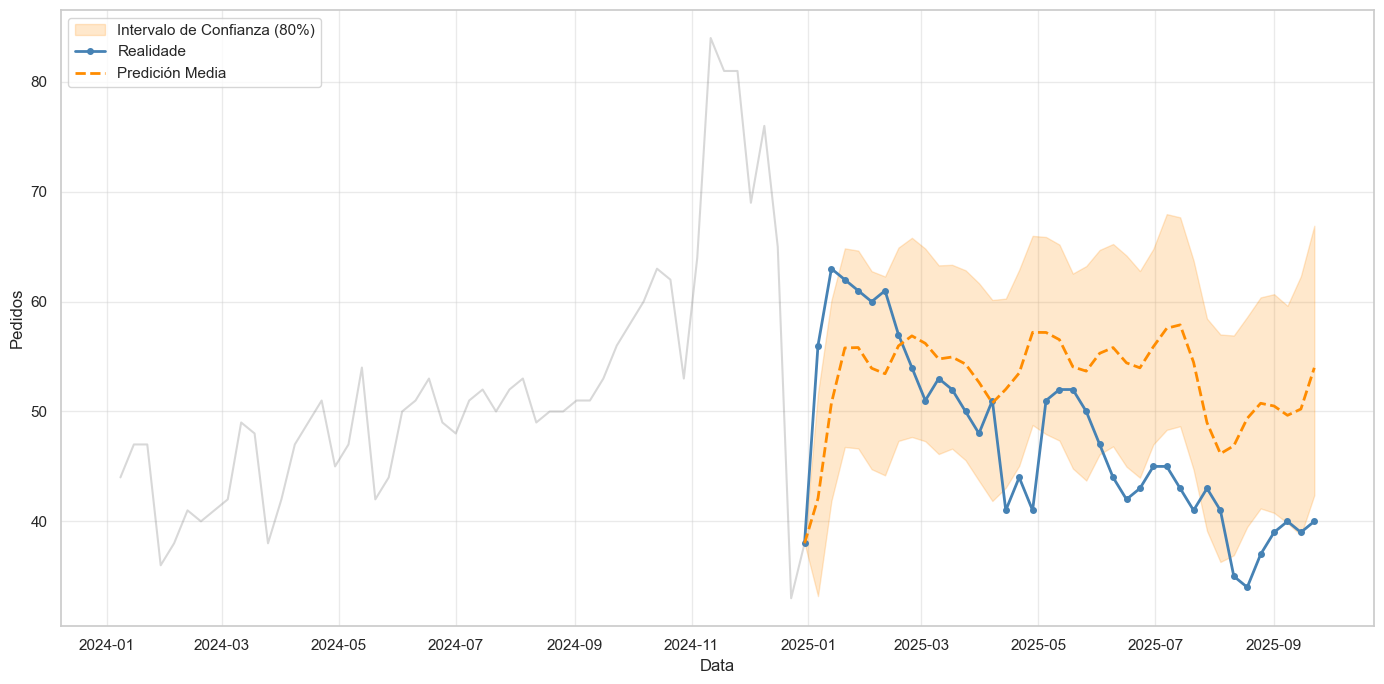

In [122]:
print(f"\n---  ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza 
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [123]:
# Cálculo de Métricas 
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- AVALIACIÓN: Prophet - Cluster 2 ---
MAE:  8.46
RMSE: 9.57
MAPE: 19.21%
MASE: 0.59 (Estacional (m=52))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


18:53:59 - cmdstanpy - INFO - Chain [1] start processing
18:53:59 - cmdstanpy - INFO - Chain [1] done processing


   Xerando compoñentes...


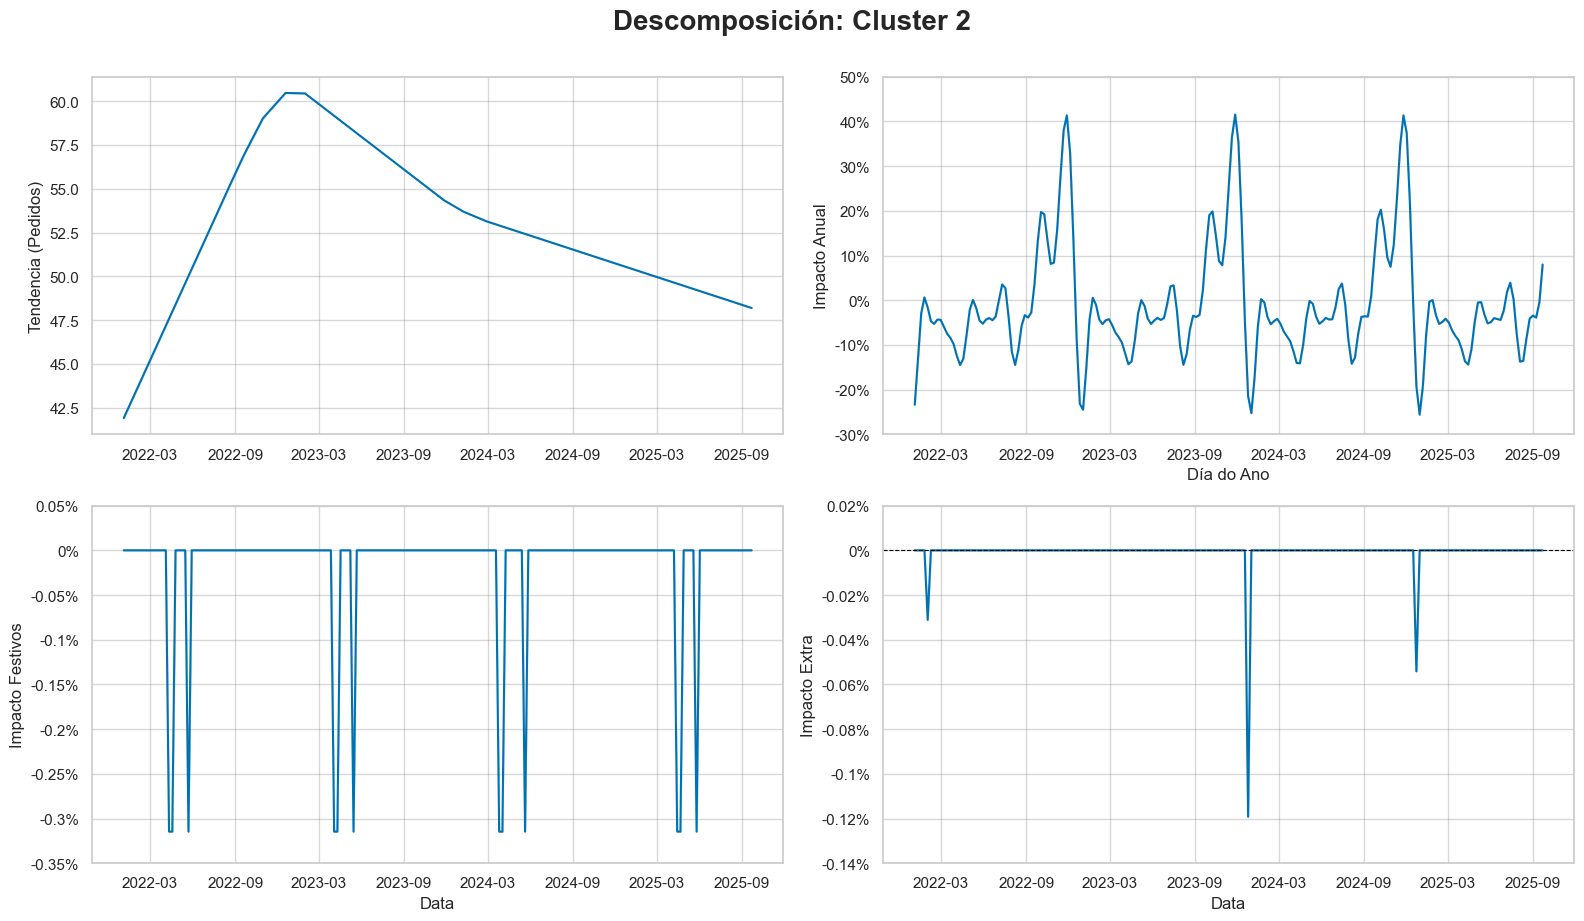

In [124]:
# Compoñentes 
print("   Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), 
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

### Cluster 3

Por último, axustamos os modelos Prophet ao noso último cluster, que contén aos clientes de alimentación e industria:

In [125]:
modelo = 'Cluster 3'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' 
)
# Gardamos no dicionario
print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 3
    Prophet Prep: Train=157, Test=38
    Regresores detectados (1): ['outlier_20220502']...
   Variables exóxenas detectadas (1): ['outlier_20220502']


In [126]:
print(f"\n--- TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.5, 0.8, 0.9], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['multiplicative']      
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"  Mellores parámetros: {resultados_prophet[modelo]['params']}")

18:54:42 - cmdstanpy - INFO - Chain [1] start processing
18:54:42 - cmdstanpy - INFO - Chain [1] done processing



--- TUNING: Cluster 3 ---
 Iniciando Grid Search con 48 combinacións...


18:54:44 - cmdstanpy - INFO - Chain [1] start processing
18:54:44 - cmdstanpy - INFO - Chain [1] start processing
18:54:44 - cmdstanpy - INFO - Chain [1] start processing
18:54:44 - cmdstanpy - INFO - Chain [1] start processing
18:54:44 - cmdstanpy - INFO - Chain [1] start processing
18:54:44 - cmdstanpy - INFO - Chain [1] start processing
18:54:44 - cmdstanpy - INFO - Chain [1] done processing
18:54:44 - cmdstanpy - INFO - Chain [1] done processing
18:54:44 - cmdstanpy - INFO - Chain [1] done processing
18:54:44 - cmdstanpy - INFO - Chain [1] done processing
18:54:44 - cmdstanpy - INFO - Chain [1] done processing
18:54:45 - cmdstanpy - INFO - Chain [1] done processing
18:54:45 - cmdstanpy - INFO - Chain [1] start processing
18:54:45 - cmdstanpy - INFO - Chain [1] done processing
18:54:46 - cmdstanpy - INFO - Chain [1] start processing
18:54:47 - cmdstanpy - INFO - Chain [1] start processing
18:54:47 - cmdstanpy - INFO - Chain [1] start processing
18:54:47 - cmdstanpy - INFO - Chain [1

   > Combinación 5/48: RMSE=7.0722


18:54:57 - cmdstanpy - INFO - Chain [1] start processing
18:54:57 - cmdstanpy - INFO - Chain [1] done processing
18:54:57 - cmdstanpy - INFO - Chain [1] start processing
18:54:57 - cmdstanpy - INFO - Chain [1] start processing
18:54:57 - cmdstanpy - INFO - Chain [1] done processing
18:54:57 - cmdstanpy - INFO - Chain [1] start processing
18:54:57 - cmdstanpy - INFO - Chain [1] start processing
18:54:57 - cmdstanpy - INFO - Chain [1] done processing
18:54:57 - cmdstanpy - INFO - Chain [1] start processing
18:54:57 - cmdstanpy - INFO - Chain [1] done processing
18:54:57 - cmdstanpy - INFO - Chain [1] done processing
18:54:58 - cmdstanpy - INFO - Chain [1] done processing
18:54:58 - cmdstanpy - INFO - Chain [1] start processing
18:54:58 - cmdstanpy - INFO - Chain [1] done processing
18:55:00 - cmdstanpy - INFO - Chain [1] start processing
18:55:00 - cmdstanpy - INFO - Chain [1] start processing
18:55:00 - cmdstanpy - INFO - Chain [1] done processing
18:55:00 - cmdstanpy - INFO - Chain [1]

...

18:57:20 - cmdstanpy - INFO - Chain [1] done processing
18:57:22 - cmdstanpy - INFO - Chain [1] start processing
18:57:22 - cmdstanpy - INFO - Chain [1] start processing
18:57:22 - cmdstanpy - INFO - Chain [1] start processing
18:57:22 - cmdstanpy - INFO - Chain [1] start processing
18:57:22 - cmdstanpy - INFO - Chain [1] start processing
18:57:22 - cmdstanpy - INFO - Chain [1] start processing
18:57:22 - cmdstanpy - INFO - Chain [1] done processing
18:57:22 - cmdstanpy - INFO - Chain [1] done processing
18:57:22 - cmdstanpy - INFO - Chain [1] done processing
18:57:22 - cmdstanpy - INFO - Chain [1] done processing
18:57:23 - cmdstanpy - INFO - Chain [1] done processing
18:57:24 - cmdstanpy - INFO - Chain [1] done processing
18:57:24 - cmdstanpy - INFO - Chain [1] start processing
18:57:24 - cmdstanpy - INFO - Chain [1] done processing
18:57:26 - cmdstanpy - INFO - Chain [1] start processing
18:57:26 - cmdstanpy - INFO - Chain [1] start processing
18:57:26 - cmdstanpy - INFO - Chain [1]

   > Combinación 45/48: RMSE=8.2499


18:57:40 - cmdstanpy - INFO - Chain [1] done processing
18:57:42 - cmdstanpy - INFO - Chain [1] start processing
18:57:42 - cmdstanpy - INFO - Chain [1] start processing
18:57:42 - cmdstanpy - INFO - Chain [1] start processing
18:57:42 - cmdstanpy - INFO - Chain [1] start processing
18:57:42 - cmdstanpy - INFO - Chain [1] start processing
18:57:42 - cmdstanpy - INFO - Chain [1] start processing
18:57:42 - cmdstanpy - INFO - Chain [1] done processing
18:57:42 - cmdstanpy - INFO - Chain [1] done processing
18:57:42 - cmdstanpy - INFO - Chain [1] done processing
18:57:43 - cmdstanpy - INFO - Chain [1] done processing
18:57:43 - cmdstanpy - INFO - Chain [1] done processing
18:57:44 - cmdstanpy - INFO - Chain [1] done processing
18:57:44 - cmdstanpy - INFO - Chain [1] start processing
18:57:45 - cmdstanpy - INFO - Chain [1] done processing
18:57:47 - cmdstanpy - INFO - Chain [1] start processing
18:57:47 - cmdstanpy - INFO - Chain [1] start processing
18:57:47 - cmdstanpy - INFO - Chain [1]


 Grid Search Completado.
   Mellor RMSE: 6.7486
   Parámetros: {'changepoint_prior_scale': 0.8, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}
  Mellores parámetros: {'changepoint_prior_scale': 0.8, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}


18:57:54 - cmdstanpy - INFO - Chain [1] done processing


In [127]:
print(f"\n---  ROLLING WINDOW: {modelo} ---")

resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'], 
    verbose=True
)

18:59:23 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing



---  ROLLING WINDOW: Cluster 3 ---
 Iniciando Prophet Rolling Window (38 pasos)...


18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] 

   > Semana 10/38: Pred=25.13


18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:24 - cmdstanpy - INFO - Chain [1] start processing
18:59:24 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] 

   > Semana 20/38: Pred=16.43


18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:25 - cmdstanpy - INFO - Chain [1] start processing
18:59:25 - cmdstanpy - INFO - Chain [1] done processing
18:59:26 - cmdstanpy - INFO - Chain [1] start processing
18:59:26 - cmdstanpy - INFO - Chain [1] done processing
18:59:26 - cmdstanpy - INFO - Chain [1] 

   > Semana 30/38: Pred=19.58


18:59:26 - cmdstanpy - INFO - Chain [1] done processing
18:59:26 - cmdstanpy - INFO - Chain [1] start processing
18:59:26 - cmdstanpy - INFO - Chain [1] done processing
18:59:26 - cmdstanpy - INFO - Chain [1] start processing
18:59:26 - cmdstanpy - INFO - Chain [1] done processing
18:59:26 - cmdstanpy - INFO - Chain [1] start processing
18:59:26 - cmdstanpy - INFO - Chain [1] done processing
18:59:26 - cmdstanpy - INFO - Chain [1] start processing
18:59:26 - cmdstanpy - INFO - Chain [1] done processing
18:59:26 - cmdstanpy - INFO - Chain [1] start processing
18:59:26 - cmdstanpy - INFO - Chain [1] done processing



---  ANÁLISE GRÁFICA: Cluster 3 ---


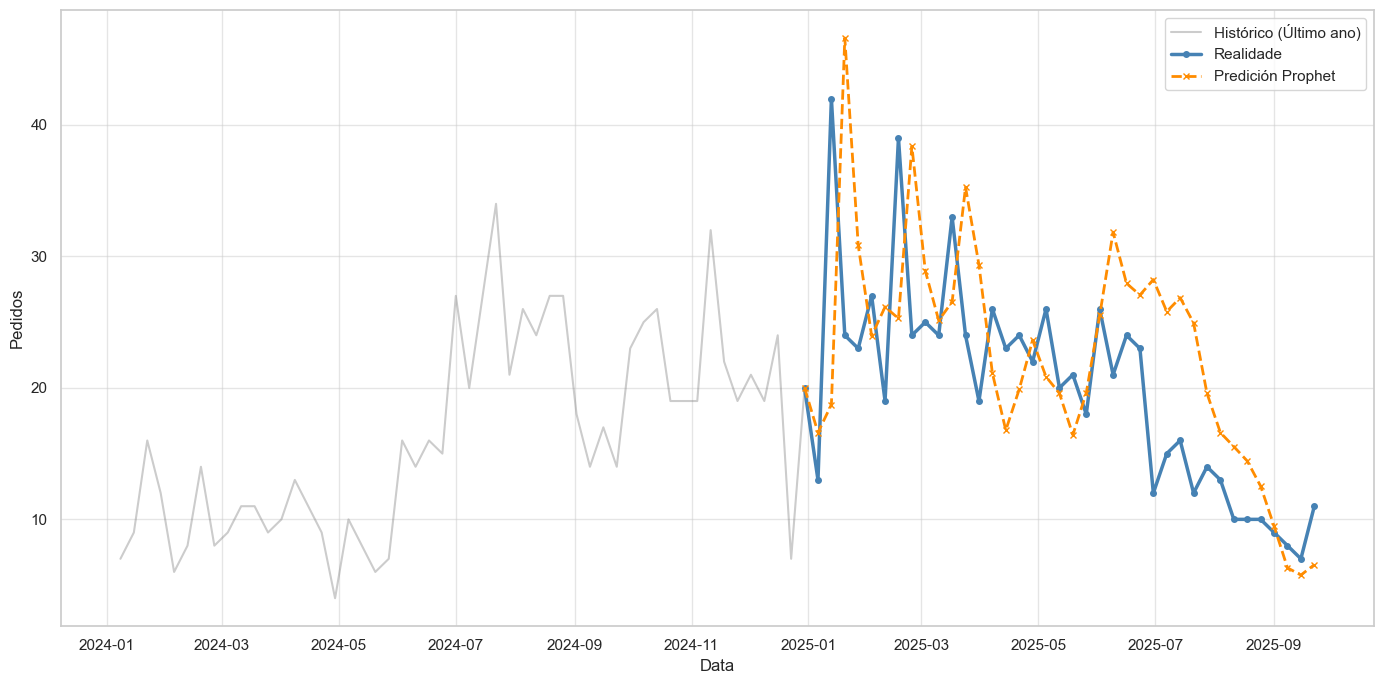

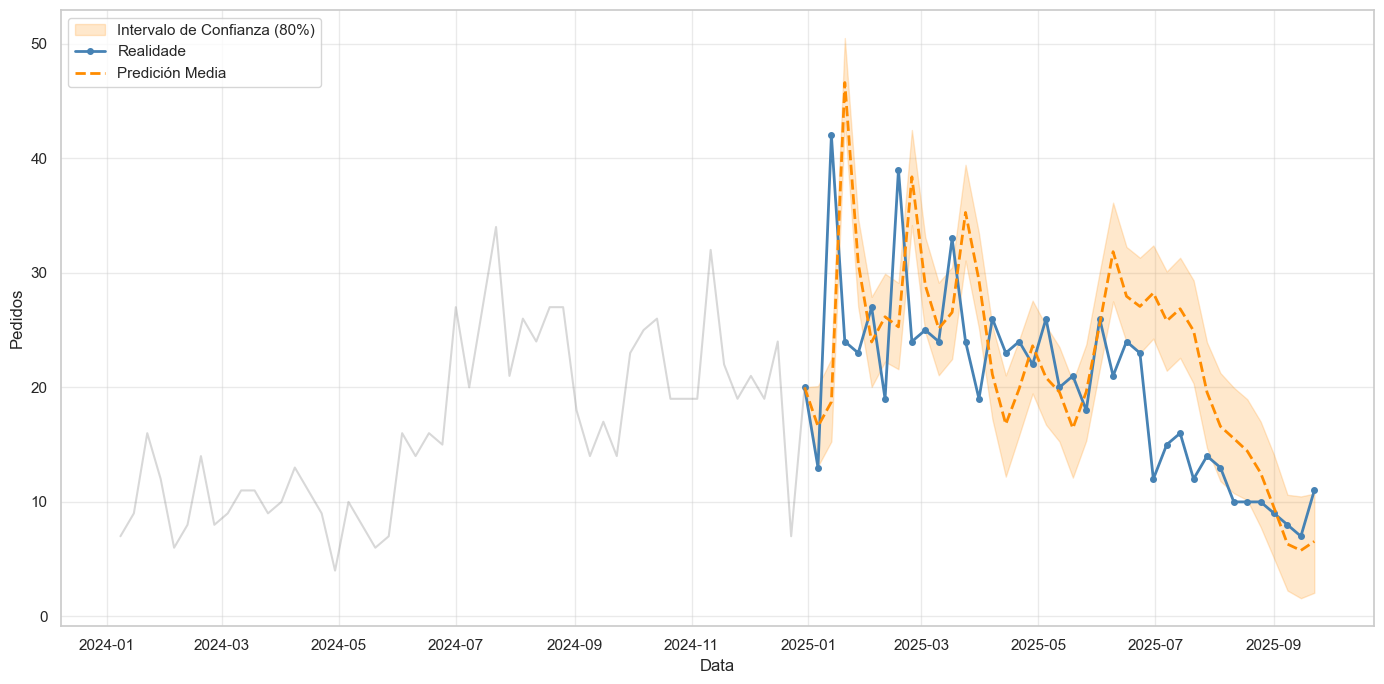

In [128]:
print(f"\n---  ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade 
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza 
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [130]:
# 2. Cálculo de Métricas 
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- AVALIACIÓN: Prophet - Cluster 3 ---
MAE:  6.76
RMSE: 8.81
MAPE: 35.99%
MASE: 0.91 (Estacional (m=52))
 CONCLUSIÓN: O modelo aporta valor (MASE < 1).


19:00:08 - cmdstanpy - INFO - Chain [1] start processing
19:00:08 - cmdstanpy - INFO - Chain [1] done processing


 Xerando compoñentes...


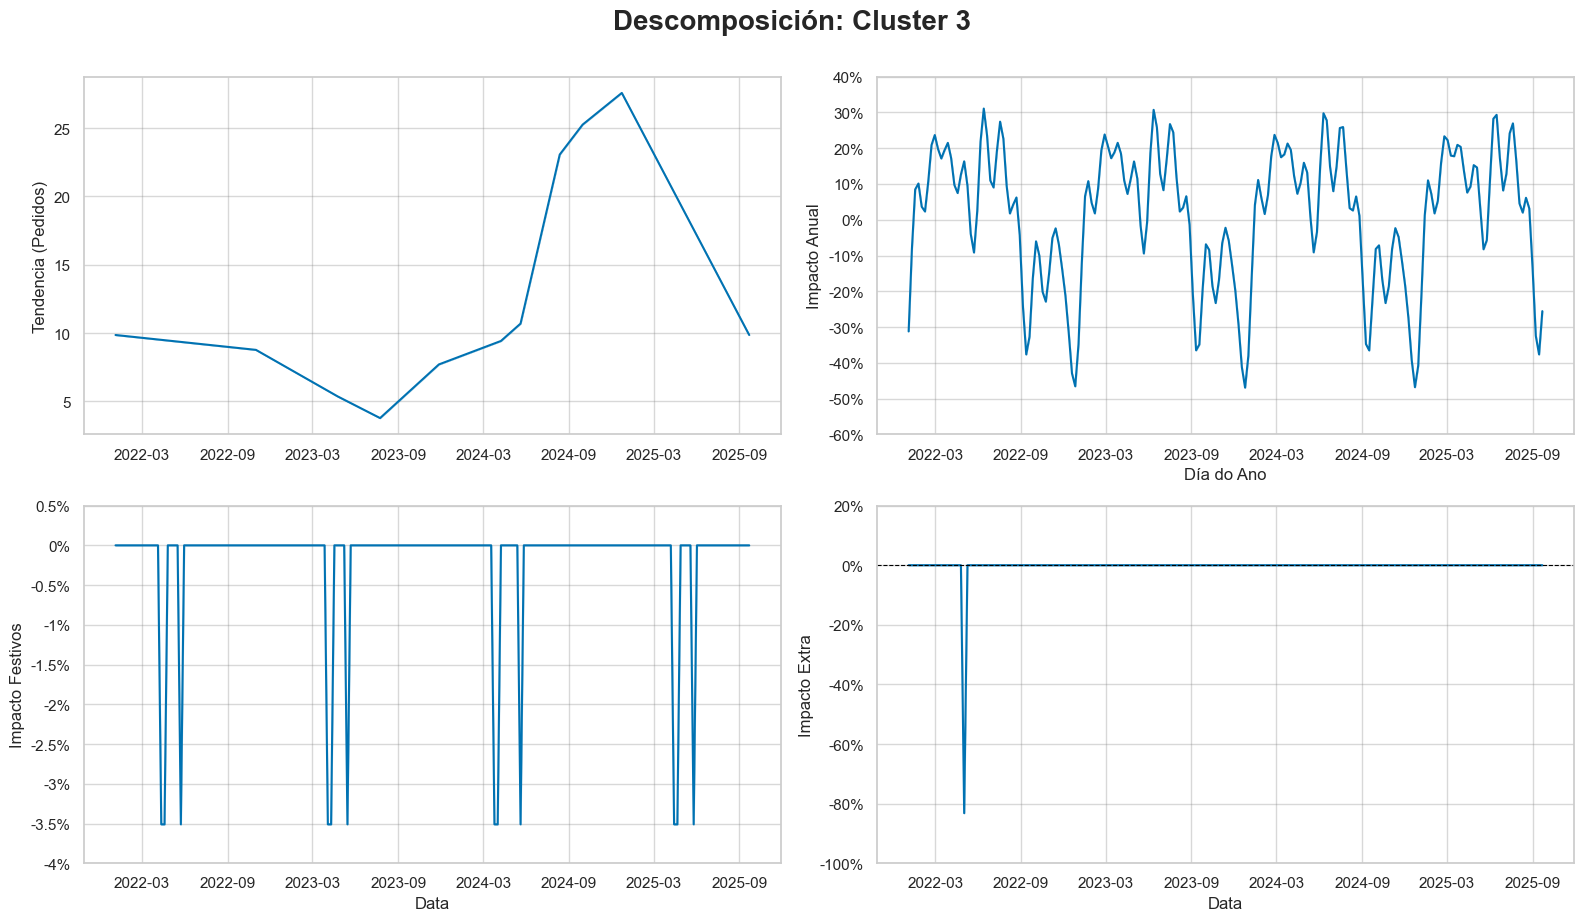

In [131]:
# Compoñentes 
print(" Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), 
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)